In [ ]:
"""Funciones de preprocesamiento para imágenes de alimentos"""

import cv2
import numpy as np
from pathlib import Path
import pandas as pd

# ============================================================
# FUNCIONES BÁSICAS DE CARGA Y CONVERSIÓN
# ============================================================

def cargar_imagen(ruta):
    """Carga una imagen desde una ruta"""
    img = cv2.imread(ruta)
    return img

def convertir_bgr_a_rgb(img):
    """Convierte una imagen de BGR a RGB"""
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img_rgb

def convertir_a_grises(img):
    """Convierte una imagen a escala de grises"""
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img_gray

def redimensionar_imagen(img, ancho, alto):
    """Redimensiona una imagen al tamaño especificado"""
    img_resized = cv2.resize(img, (ancho, alto))
    return img_resized

# ============================================================
# FUNCIONES DE ANÁLISIS DE COLOR
# ============================================================

def separar_canales_rgb(img_rgb):
    """Separa los canales RGB de una imagen"""
    r_channel = img_rgb[:, :, 0]
    g_channel = img_rgb[:, :, 1]
    b_channel = img_rgb[:, :, 2]
    return r_channel, g_channel, b_channel

def calcular_intensidad_promedio(canal):
    """Calcula la intensidad promedio de un canal"""
    return canal.mean()

# ============================================================
# FUNCIONES DE FILTRADO (REDUCCIÓN DE RUIDO)
# ============================================================

def filtro_gaussiano(img, kernel_size=(5, 5), sigma=0):
    """Aplica filtro gaussiano para suavizado"""
    gaussiano = cv2.GaussianBlur(img, kernel_size, sigma)
    return gaussiano

def filtro_mediana(img, kernel_size=5):
    """Aplica filtro de mediana"""
    mediana = cv2.medianBlur(img, kernel_size)
    return mediana

def filtro_promedio(img, kernel_size=(5, 5)):
    """Aplica filtro promedio"""
    promedio = cv2.blur(img, kernel_size)
    return promedio

# ============================================================
# FUNCIONES DE BINARIZACIÓN (SEGMENTACIÓN)
# ============================================================

def entropy_threshold(image):
    """Calcula el umbral óptimo usando el método de entropía"""
    hist, bins = np.histogram(image.flatten(), 256, [0, 256])
    hist = hist.astype(float)
    hist_norm = hist / hist.sum()
    
    max_entropy = 0
    optimal_threshold = 0
    
    for t in range(1, 255):
        w0 = np.sum(hist_norm[:t])
        w1 = np.sum(hist_norm[t:])
        
        if w0 == 0 or w1 == 0:
            continue
        
        h0 = hist_norm[:t] / w0
        h1 = hist_norm[t:] / w1
        
        h0 = h0[h0 > 0]
        h1 = h1[h1 > 0]
        
        entropy0 = -np.sum(h0 * np.log2(h0)) if len(h0) > 0 else 0
        entropy1 = -np.sum(h1 * np.log2(h1)) if len(h1) > 0 else 0
        
        total_entropy = w0 * entropy0 + w1 * entropy1
        
        if total_entropy > max_entropy:
            max_entropy = total_entropy
            optimal_threshold = t
    
    return optimal_threshold

def binarizar_umbral_fijo(img_gray, umbral=127):
    """Binariza una imagen usando un umbral fijo"""
    _, img_binary = cv2.threshold(img_gray, umbral, 255, cv2.THRESH_BINARY)
    return img_binary

def binarizar_otsu(img_gray):
    """Binariza una imagen usando el método de Otsu"""
    umbral, img_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return umbral, img_otsu

def binarizar_entropia(img_gray):
    """Binariza una imagen usando el método de entropía"""
    umbral = entropy_threshold(img_gray)
    _, img_entropy = cv2.threshold(img_gray, umbral, 255, cv2.THRESH_BINARY)
    return umbral, img_entropy

# ============================================================
# FUNCIONES DE DETECCIÓN DE BORDES
# ============================================================

def filtro_canny(img_gray, umbral_bajo=100, umbral_alto=200):
    """Aplica detector de bordes Canny"""
    canny = cv2.Canny(img_gray, umbral_bajo, umbral_alto)
    return canny

def filtro_sobel(img_gray, ksize=3):
    """Aplica filtro Sobel para detección de bordes"""
    sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=ksize)
    sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=ksize)
    sobel = cv2.magnitude(sobelx, sobely)
    sobel = cv2.convertScaleAbs(sobel)
    return sobel

def filtro_laplaciano(img_gray):
    """Aplica filtro laplaciano para detección de bordes"""
    laplaciano = cv2.Laplacian(img_gray, cv2.CV_64F)
    laplaciano = cv2.convertScaleAbs(laplaciano)
    return laplaciano

def filtro_prewitt(img_gray):
    """Aplica filtro Prewitt para detección de bordes"""
    kernel_prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
    kernel_prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)
    prewitt_x = cv2.filter2D(img_gray, -1, kernel_prewitt_x)
    prewitt_y = cv2.filter2D(img_gray, -1, kernel_prewitt_y)
    prewitt = cv2.convertScaleAbs(prewitt_x + prewitt_y)
    return prewitt

# ============================================================
# FUNCIONES DE MORFOLOGÍA (LIMPIEZA Y MEJORA)
# ============================================================

def morfologia_apertura(img_bin, kernel_size=(7, 7)):
    """Aplica operación morfológica de apertura (elimina ruido)"""
    kernel = np.ones(kernel_size, np.uint8)
    opening = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernel)
    return opening

def morfologia_cierre(img_bin, kernel_size=(7, 7)):
    """Aplica operación morfológica de cierre (rellena huecos)"""
    kernel = np.ones(kernel_size, np.uint8)
    closing = cv2.morphologyEx(img_bin, cv2.MORPH_CLOSE, kernel)
    return closing

# ============================================================
# FUNCIONES DE OPERACIONES ENTRE IMÁGENES
# ============================================================

def diferencia_absoluta(img1, img2):
    """Calcula la diferencia absoluta entre dos imágenes"""
    diff_abs = cv2.absdiff(img1, img2)
    return diff_abs

# ============================================================
# FUNCIONES DE DETECCIÓN DE CONTORNOS
# ============================================================

def detectar_contornos(img_bin):
    """Detecta contornos en una imagen binaria"""
    contours, _ = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return contours

def dibujar_contornos(img, contornos, color=(0, 255, 0), grosor=2):
    """Dibuja contornos en una imagen"""
    img_contornos = cv2.drawContours(np.copy(img), contornos, -1, color, grosor)
    return img_contornos

# ============================================================
#  PREPROCESAMIENTO PARA HAMBURGUESAS
# ============================================================

# Directorios
IMAGES_DIR = Path('imagenes')
OUTPUT_DIR = Path('imagenes_preprocesadas')
OUTPUT_DIR.mkdir(exist_ok=True)

# Listar imágenes
EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
image_paths = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in EXTS])

print(f"🔄 Procesando {len(image_paths)} imágenes...")
print("=" * 60)

resultados = []

for idx, img_path in enumerate(image_paths, 1):
    print(f"[{idx}/{len(image_paths)}] {img_path.name}...", end=" ")
    
    try:
        # 1. Cargar imagen original
        img = cargar_imagen(str(img_path))
        if img is None:
            print("❌ Error al cargar")
            continue
        
        # 2. Convertir a escala de grises
        img_gray = convertir_a_grises(img)
        
        # 3. Aplicar filtro gaussiano para reducir ruido
        img_blur = filtro_gaussiano(img_gray, kernel_size=(5, 5), sigma=1.5)

        # 4. Detectar bordes usando Canny
        edges = filtro_canny(img_blur, umbral_bajo=50, umbral_alto=150)
        
        # 5. Aplicar cierre morfológico para conectar bordes cercanos y completar contornos
        edges_closed = morfologia_cierre(edges, kernel_size=(5, 5))
        
        # 6. Detectar contornos
        contornos = detectar_contornos(edges_closed)
        
        if len(contornos) == 0:
            print("⚠️ Sin contornos")
            continue
        
        # 7. Filtrar contornos por área (quedarnos con los más grandes, eliminar ruido pequeño)
        area_total = img_gray.shape[0] * img_gray.shape[1]
        area_minima = area_total * 0.05  # Al menos 5% del área total
        contornos_grandes = [c for c in contornos if cv2.contourArea(c) >= area_minima]
        
        if len(contornos_grandes) == 0:
            print("⚠️ Sin contornos significativos")
            continue
        
        # 8. Encontrar el contorno más grande y central (la hamburguesa principal)
        centro_img = (img_gray.shape[1] // 2, img_gray.shape[0] // 2)
        
        def score_contorno(contorno):
            """Puntaje basado en área y proximidad al centro"""
            area = cv2.contourArea(contorno)
            M = cv2.moments(contorno)
            if M['m00'] != 0:
                cx = int(M['m10'] / M['m00'])
                cy = int(M['m01'] / M['m00'])
                dist_centro = np.sqrt((cx - centro_img[0])**2 + (cy - centro_img[1])**2)
                # Mayor puntaje = mayor área y más cercano al centro
                return area - (dist_centro * 0.5)
            return area
        
        contorno_principal = max(contornos_grandes, key=score_contorno)
        
        # 9. Crear máscara solo con el contorno principal (eliminar ruido alejado)
        mascara_principal = np.zeros(img_gray.shape, dtype=np.uint8)
        cv2.drawContours(mascara_principal, [contorno_principal], -1, 255, thickness=cv2.FILLED)
        
        # 10. Aplicar la máscara a los bordes originales para quedarnos solo con bordes de la hamburguesa
        edges_hamburguesa = cv2.bitwise_and(edges_closed, edges_closed, mask=mascara_principal)
        
        # 11. Obtener información del contorno principal
        x, y, w, h = cv2.boundingRect(contorno_principal)
        area_contorno = cv2.contourArea(contorno_principal)
        porcentaje_area = (area_contorno / area_total) * 100
        
        # 12. Crear imagen a color con los bordes superpuestos (solo hamburguesa)
        img_con_bordes = img.copy()
        # Crear máscara donde están los bordes de la hamburguesa
        mask_bordes = edges_hamburguesa > 0
        # Pintar los bordes en verde brillante sobre la imagen original
        img_con_bordes[mask_bordes] = [0, 255, 0]  # Verde en BGR
        
        # 13. Guardar la imagen a color con bordes
        output_path = OUTPUT_DIR / f"{img_path.stem}_procesada{img_path.suffix}"
        cv2.imwrite(str(output_path), img_con_bordes)
        
        print(f"✅ Guardada - Hamburguesa aislada: {w}x{h}px ({porcentaje_area:.1f}% del área)")
        
        resultados.append({
            'Imagen': img_path.name,
            'Num_Contornos': len(contornos),
            'Área_Mayor': int(area_contorno),
            'Porcentaje_Área': f"{porcentaje_area:.2f}%",
            'Dimensiones': f"{w}x{h}",
            'Salida': output_path.name
        })
        
    except Exception as e:
        print(f"❌ Error: {e}")

print("=" * 60)
print(f"✅ Procesamiento completado: {len(resultados)}/{len(image_paths)} imágenes")
print(f"📁 Imágenes guardadas en: {OUTPUT_DIR.resolve()}")

# Mostrar resumen
df_resultados = pd.DataFrame(resultados)
df_resultados

🔄 Procesando 10 imágenes...
[1/10] hamburguesa1.jpg... ✅ Guardada - Hamburguesa aislada: 498x313px (17.1% del área)
[2/10] hamburguesa10.jpg... ⚠️ Sin contornos significativos
[3/10] hamburguesa2.jpeg... ✅ Guardada - Hamburguesa aislada: 445x367px (31.5% del área)
[4/10] hamburguesa3.jpg... ⚠️ Sin contornos significativos
[5/10] hamburguesa4.jpg... ⚠️ Sin contornos significativos
[6/10] hamburguesa5.jpg... ⚠️ Sin contornos significativos
[7/10] hamburguesa6.jpg... ✅ Guardada - Hamburguesa aislada: 970x618px (36.8% del área)
[8/10] hamburguesa7.jpg... ✅ Guardada - Hamburguesa aislada: 206x183px (42.2% del área)
[9/10] hamburguesa8.jpg... ✅ Guardada - Hamburguesa aislada: 541x352px (43.8% del área)
[10/10] hamburguesa9.jpg... ✅ Guardada - Hamburguesa aislada: 768x611px (13.8% del área)
✅ Procesamiento completado: 6/10 imágenes
📁 Imágenes guardadas en: C:\Users\NAPACHE\Documents\Universidad\Vision Artificial\Parciales\Parcial2\parcial1VisionArtificial\temasClaseParcial2\imagenes_preproces

,Imagen,Num_Contornos,Área_Mayor,Porcentaje_Área,Dimensiones,Salida
0,hamburguesa1.jpg,28,50229,17.13%,498x313,hamburguesa1_procesada.jpg
1,hamburguesa2.jpeg,6,84510,31.48%,445x367,hamburguesa2_procesada.jpeg
2,hamburguesa6.jpg,12,367958,36.80%,970x618,hamburguesa6_procesada.jpg
3,hamburguesa7.jpg,6,21344,42.16%,206x183,hamburguesa7_procesada.jpg
4,hamburguesa8.jpg,20,115762,43.76%,541x352,hamburguesa8_procesada.jpg
5,hamburguesa9.jpg,68,127503,13.83%,768x611,hamburguesa9_procesada.jpg


In [2]:
import os
from pathlib import Path
import cv2
import numpy as np
import pandas as pd

# Directorio de imágenes
IMAGES_DIR = Path('imagenes_preprocesadas')
if not IMAGES_DIR.exists():
    raise FileNotFoundError(f"No se encontró el directorio de imágenes: {IMAGES_DIR.resolve()}")

# Extensiones soportadas
EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

# Listar las 10 imágenes
image_paths = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in EXTS])
if not image_paths:
    raise RuntimeError(f"No se encontraron imágenes con extensiones {EXTS} en {IMAGES_DIR.resolve()}")

# Función de entropía basada en el histograma (Shannon)
def entropy_shannon(gray_img):
    hist, _ = np.histogram(gray_img, bins=256, range=(0, 256))
    p = hist.astype(np.float64)
    p /= p.sum() if p.sum() > 0 else 1.0
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

rows = []
for img_path in image_paths:
    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"Advertencia: No se pudo leer {img_path.name}")
        continue

    mean = float(np.mean(image))
    variance = float(np.var(image))
    std_dev = float(np.std(image))
    entropy = entropy_shannon(image)

    rows.append({
        'Imagen': img_path.name,
        'Media': mean,
        'Varianza': variance,
        'Desviación_Estándar': std_dev,
        'Entropía': entropy
    })

stats_df = pd.DataFrame(rows)
print(f"Imágenes procesadas: {len(stats_df)}/{len(image_paths)} en '{IMAGES_DIR}'")

# Calcular distancias euclidianas entre todas las imágenes
print("\n" + "="*60)
print("DISTANCIAS EUCLIDIANAS - Estadísticas Básicas")
print("="*60)

# Extraer solo las características numéricas (excluir nombre de imagen)
features = stats_df[['Media', 'Varianza', 'Desviación_Estándar', 'Entropía']].values
image_names = stats_df['Imagen'].values

# Matriz de distancias
n = len(features)
distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])

# Crear DataFrame de distancias
dist_df = pd.DataFrame(distance_matrix, 
                       index=image_names, 
                       columns=image_names)

print("\nMatriz de distancias euclidianas:")
print(dist_df.round(2))

# Encontrar pares más similares y más diferentes
print("\n" + "-"*60)
print("ANÁLISIS DE SIMILITUD")
print("-"*60)

# Obtener triángulo superior sin diagonal
indices = np.triu_indices(n, k=1)
distances = distance_matrix[indices]
pairs = [(image_names[i], image_names[j], distance_matrix[i, j]) 
         for i, j in zip(indices[0], indices[1])]

# Ordenar por distancia
pairs_sorted = sorted(pairs, key=lambda x: x[2])

print("\n🟢 Top 5 pares MÁS SIMILARES (menor distancia):")
for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.4f}")

print("\n🔴 Top 5 pares MÁS DIFERENTES (mayor distancia):")
for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.4f}")

stats_df

Imágenes procesadas: 10/10 en 'imagenes_preprocesadas'

DISTANCIAS EUCLIDIANAS - Estadísticas Básicas

Matriz de distancias euclidianas:
                             hamburguesa10_procesada.jpg  \
hamburguesa10_procesada.jpg                         0.00   
hamburguesa1_procesada.jpg                       1593.77   
hamburguesa2_procesada.jpeg                        81.02   
hamburguesa3_procesada.jpg                       1801.44   
hamburguesa4_procesada.jpg                       2520.18   
hamburguesa5_procesada.jpg                       2247.52   
hamburguesa6_procesada.jpg                        817.86   
hamburguesa7_procesada.jpg                        863.95   
hamburguesa8_procesada.jpg                       1641.09   
hamburguesa9_procesada.jpg                       1290.89   

                             hamburguesa1_procesada.jpg  \
hamburguesa10_procesada.jpg                     1593.77   
hamburguesa1_procesada.jpg                         0.00   
hamburguesa2_procesada.jp

,Imagen,Media,Varianza,Desviación_Estándar,Entropía
0,hamburguesa10_procesada.jpg,151.152214,4869.149480,69.779291,7.870937
1,hamburguesa1_procesada.jpg,118.062251,3275.774783,57.234385,7.571103
2,hamburguesa2_procesada.jpeg,72.167968,4887.073910,69.907610,5.751517
3,hamburguesa3_procesada.jpg,109.630900,3068.245697,55.391748,7.617979
4,hamburguesa4_procesada.jpg,129.417183,2349.155424,48.468087,7.563721
5,hamburguesa5_procesada.jpg,80.307898,2622.819305,51.213468,7.067403
6,hamburguesa6_procesada.jpg,62.799050,5682.197469,75.380352,4.546638
7,hamburguesa7_procesada.jpg,92.181215,4007.240682,63.302770,7.214627
8,hamburguesa8_procesada.jpg,103.134202,3228.818202,56.822691,7.264470
9,hamburguesa9_procesada.jpg,83.514795,3580.072283,59.833705,7.062011


In [3]:
import numpy as np
import cv2
from pathlib import Path
from skimage.feature import graycomatrix, graycoprops
from skimage import img_as_ubyte
import pandas as pd

# Reutilizar directorio de imágenes
IMAGES_DIR = Path('imagenes_preprocesadas')
EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
image_paths = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in EXTS])

rows = []
for img_path in image_paths:
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Advertencia: No se pudo leer {img_path.name}")
        continue
    img = img_as_ubyte(img)

    # GLCM para varias distancias y ángulos (ejemplo: 1 píxel y 0°)
    glcm = graycomatrix(img, distances=[1], angles=[0], symmetric=True, normed=True)

    contrast = float(graycoprops(glcm, prop='contrast'))
    homogeneity = float(graycoprops(glcm, prop='homogeneity'))
    dissimilarity = float(graycoprops(glcm, prop='dissimilarity'))
    energy = float(graycoprops(glcm, prop='energy'))
    correlation = float(graycoprops(glcm, prop='correlation'))

    mean_glcm = float(np.mean(glcm))
    std_dev_glcm = float(np.std(glcm))
    glcm_flat = glcm.flatten()
    glcm_flat = glcm_flat[glcm_flat > 0]
    entropy_glcm = float(-np.sum(glcm_flat * np.log(glcm_flat)))

    rows.append({
        'Imagen': img_path.name,
        'Contraste': contrast,
        'Homogeneidad': homogeneity,
        'Disimilitud': dissimilarity,
        'Energía': energy,
        'Correlación': correlation,
        'GLCM_Media': mean_glcm,
        'GLCM_Std': std_dev_glcm,
        'GLCM_Entropía': entropy_glcm
    })

glcm_df = pd.DataFrame(rows)
print(f"GLCM calculada para {len(glcm_df)} imágenes.")

# Calcular distancias euclidianas entre todas las imágenes
print("\n" + "="*60)
print("DISTANCIAS EUCLIDIANAS - Características GLCM")
print("="*60)

# Extraer características numéricas
feature_cols = ['Contraste', 'Homogeneidad', 'Disimilitud', 'Energía', 
                'Correlación', 'GLCM_Media', 'GLCM_Std', 'GLCM_Entropía']
features = glcm_df[feature_cols].values
image_names = glcm_df['Imagen'].values

# Matriz de distancias
n = len(features)
distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])

# Crear DataFrame de distancias
dist_df = pd.DataFrame(distance_matrix, 
                       index=image_names, 
                       columns=image_names)

print("\nMatriz de distancias euclidianas:")
print(dist_df.round(2))

# Análisis de similitud
indices = np.triu_indices(n, k=1)
pairs = [(image_names[i], image_names[j], distance_matrix[i, j]) 
         for i, j in zip(indices[0], indices[1])]
pairs_sorted = sorted(pairs, key=lambda x: x[2])

print("\n" + "-"*60)
print("ANÁLISIS DE SIMILITUD")
print("-"*60)

print("\n🟢 Top 5 pares MÁS SIMILARES (menor distancia):")
for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.4f}")

print("\n🔴 Top 5 pares MÁS DIFERENTES (mayor distancia):")
for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.4f}")

glcm_df

GLCM calculada para 10 imágenes.

DISTANCIAS EUCLIDIANAS - Características GLCM

Matriz de distancias euclidianas:
                             hamburguesa10_procesada.jpg  \
hamburguesa10_procesada.jpg                         0.00   
hamburguesa1_procesada.jpg                         79.31   
hamburguesa2_procesada.jpeg                       102.57   
hamburguesa3_procesada.jpg                         26.69   
hamburguesa4_procesada.jpg                        132.66   
hamburguesa5_procesada.jpg                        157.37   
hamburguesa6_procesada.jpg                        113.28   
hamburguesa7_procesada.jpg                        394.12   
hamburguesa8_procesada.jpg                        137.16   
hamburguesa9_procesada.jpg                         82.39   

                             hamburguesa1_procesada.jpg  \
hamburguesa10_procesada.jpg                       79.31   
hamburguesa1_procesada.jpg                         0.00   
hamburguesa2_procesada.jpeg                    

C:\Users\NAPACHE\AppData\Local\Temp\ipykernel_23940\398449738.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  contrast = float(graycoprops(glcm, prop='contrast'))
C:\Users\NAPACHE\AppData\Local\Temp\ipykernel_23940\398449738.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  homogeneity = float(graycoprops(glcm, prop='homogeneity'))
C:\Users\NAPACHE\AppData\Local\Temp\ipykernel_23940\398449738.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dissimilarit

,Imagen,Contraste,Homogeneidad,Disimilitud,Energía,Correlación,GLCM_Media,GLCM_Std,GLCM_Entropía
0,hamburguesa10_procesada.jpg,39.725977,0.604107,1.816643,0.042251,0.995921,0.000015,0.000164,7.365916
1,hamburguesa1_procesada.jpg,118.995137,0.405972,4.127510,0.028759,0.981838,0.000015,0.000111,7.982126
2,hamburguesa2_procesada.jpeg,142.268978,0.605123,3.589855,0.360354,0.985451,0.000015,0.001408,5.851863
3,hamburguesa3_procesada.jpg,66.398503,0.538860,2.712983,0.039544,0.989174,0.000015,0.000154,7.564393
4,hamburguesa4_procesada.jpg,172.252427,0.193226,7.621355,0.015699,0.963324,0.000015,0.000059,8.815078
5,hamburguesa5_procesada.jpg,197.065773,0.572038,4.750404,0.075317,0.962443,0.000015,0.000294,7.157604
6,hamburguesa6_procesada.jpg,152.953439,0.661513,3.745672,0.515599,0.986545,0.000015,0.002014,4.753237
7,hamburguesa7_procesada.jpg,433.786131,0.346307,8.507361,0.050507,0.945828,0.000015,0.000197,7.999575
8,hamburguesa8_procesada.jpg,176.846781,0.453248,4.968708,0.053736,0.972615,0.000015,0.000209,7.663244
9,hamburguesa9_procesada.jpg,122.100528,0.537181,3.533036,0.066243,0.982948,0.000015,0.000258,7.186503


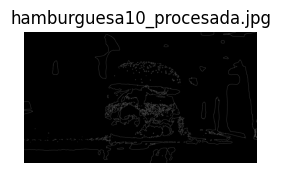

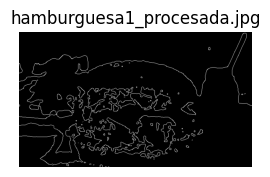

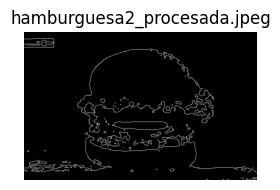

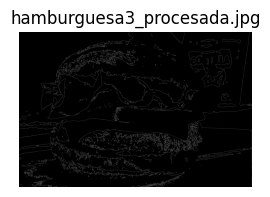

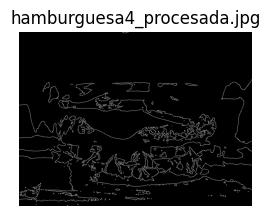

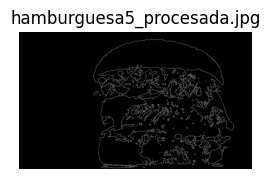

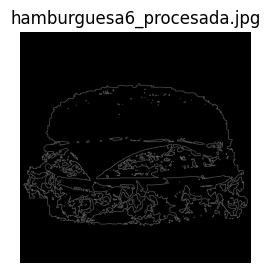

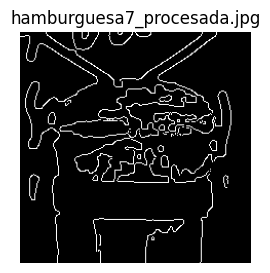

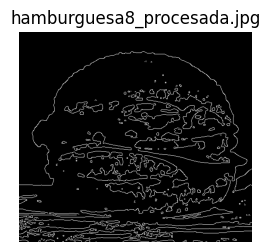

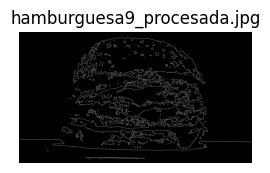

Hu (Canny) calculados para 10 imágenes.

DISTANCIAS EUCLIDIANAS - Momentos de Hu (Canny)

Matriz de distancias euclidianas:
                             hamburguesa10_procesada.jpg  \
hamburguesa10_procesada.jpg                     0.000000   
hamburguesa1_procesada.jpg                      0.016091   
hamburguesa2_procesada.jpeg                     0.009235   
hamburguesa3_procesada.jpg                      0.002248   
hamburguesa4_procesada.jpg                      0.017355   
hamburguesa5_procesada.jpg                      0.020994   
hamburguesa6_procesada.jpg                      0.016002   
hamburguesa7_procesada.jpg                      0.024474   
hamburguesa8_procesada.jpg                      0.022646   
hamburguesa9_procesada.jpg                      0.020493   

                             hamburguesa1_procesada.jpg  \
hamburguesa10_procesada.jpg                    0.016091   
hamburguesa1_procesada.jpg                     0.000000   
hamburguesa2_procesada.jpeg           

,Imagen,Hu1,Hu2,Hu3,Hu4,Hu5,Hu6,Hu7
0,hamburguesa10_procesada.jpg,0.032192,2.043470e-04,6.727337e-07,1.966841e-07,7.079058e-14,-2.500419e-09,-1.035832e-14
1,hamburguesa1_procesada.jpg,0.016102,7.898500e-05,9.708354e-07,4.821651e-07,2.792442e-13,2.223529e-09,1.756381e-13
2,hamburguesa2_procesada.jpeg,0.022958,8.558471e-05,1.454855e-06,2.917137e-07,-1.329804e-13,1.726164e-09,1.357624e-13
3,hamburguesa3_procesada.jpg,0.029948,7.710852e-05,5.884517e-07,2.942517e-07,-1.019654e-13,1.508976e-09,6.778890e-14
4,hamburguesa4_procesada.jpg,0.014838,6.226551e-05,9.531702e-08,1.180226e-09,-1.006117e-17,6.020117e-12,7.447929e-18
5,hamburguesa5_procesada.jpg,0.011200,4.289600e-06,5.044529e-09,4.588019e-09,1.196901e-17,-3.087412e-12,-1.854536e-17
6,hamburguesa6_procesada.jpg,0.016191,8.635258e-05,5.386807e-08,4.461329e-08,-6.482045e-16,-1.453519e-10,-2.088801e-15
7,hamburguesa7_procesada.jpg,0.007720,4.037820e-07,1.080282e-08,6.829276e-09,-5.591415e-17,-2.788916e-12,-1.773191e-17
8,hamburguesa8_procesada.jpg,0.009548,5.865691e-06,1.194206e-07,1.210572e-08,4.364616e-17,1.925237e-11,-4.582096e-16
9,hamburguesa9_procesada.jpg,0.011700,9.665600e-06,8.785485e-08,9.368470e-09,1.851694e-16,1.981986e-11,-1.948109e-16


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

IMAGES_DIR = Path('imagenes_preprocesadas')
image_paths = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')])

rows = []
for img_path in image_paths:
    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"No se pudo leer {img_path.name}")
        continue

    imagen_suavizada = cv2.GaussianBlur(image, (5, 5), 0)
    _, binary_image = cv2.threshold(imagen_suavizada, 107, 255, cv2.THRESH_BINARY)
    edges = cv2.Canny(binary_image, 100, 200)

    moments = cv2.moments(edges)
    hu = cv2.HuMoments(moments).flatten()

    rows.append({'Imagen': img_path.name, **{f'Hu{i+1}': float(hu[i]) for i in range(7)}})

    # Mostrar una miniatura por imagen
    plt.figure(figsize=(3, 3))
    plt.title(img_path.name)
    plt.imshow(edges, cmap='gray')
    plt.axis('off')
    plt.show()

hu_df_canny = pd.DataFrame(rows)
print(f"Hu (Canny) calculados para {len(hu_df_canny)} imágenes.")

# Calcular distancias euclidianas entre todas las imágenes
print("\n" + "="*60)
print("DISTANCIAS EUCLIDIANAS - Momentos de Hu (Canny)")
print("="*60)

# Extraer características Hu
feature_cols = [f'Hu{i+1}' for i in range(7)]
features = hu_df_canny[feature_cols].values
image_names = hu_df_canny['Imagen'].values

# Matriz de distancias
n = len(features)
distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])

# Crear DataFrame de distancias
dist_df = pd.DataFrame(distance_matrix, 
                       index=image_names, 
                       columns=image_names)

print("\nMatriz de distancias euclidianas:")
print(dist_df)

# Análisis de similitud
indices = np.triu_indices(n, k=1)
pairs = [(image_names[i], image_names[j], distance_matrix[i, j]) 
         for i, j in zip(indices[0], indices[1])]
pairs_sorted = sorted(pairs, key=lambda x: x[2])

print("\n" + "-"*60)
print("ANÁLISIS DE SIMILITUD")
print("-"*60)

print("\n🟢 Top 5 pares MÁS SIMILARES (menor distancia):")
for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.6e}")

print("\n🔴 Top 5 pares MÁS DIFERENTES (mayor distancia):")
for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.6e}")

hu_df_canny

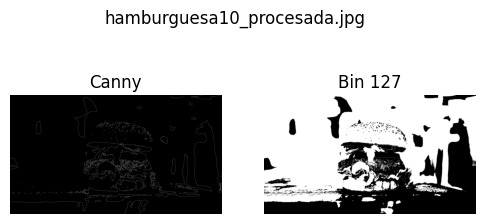

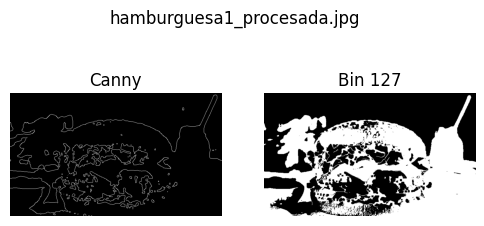

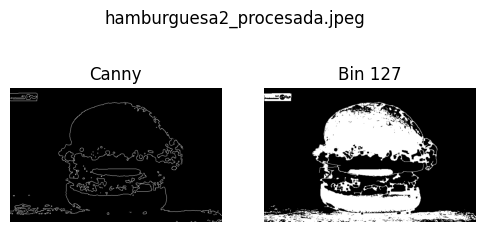

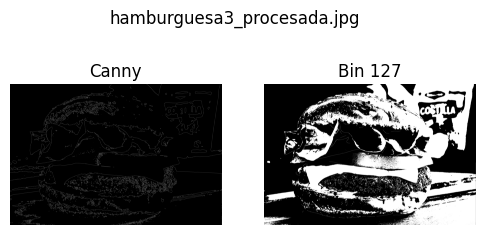

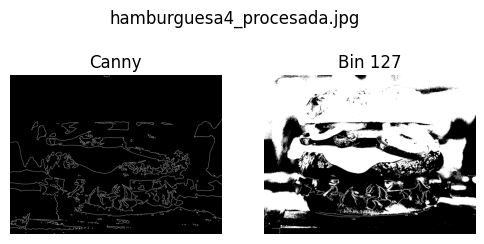

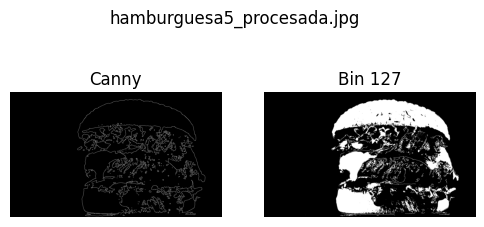

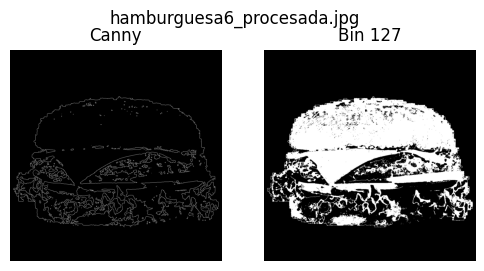

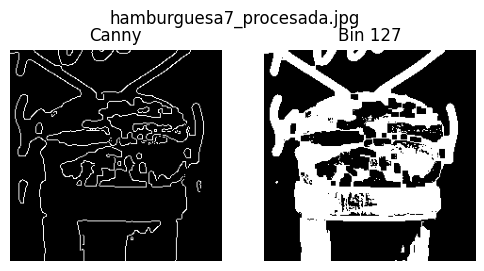

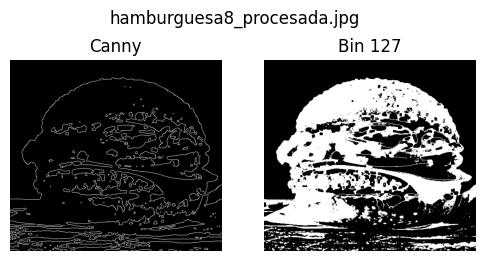

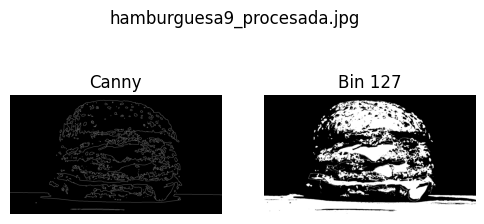

Distancias Hu (Canny vs 127):

DISTANCIAS EUCLIDIANAS - Momentos Hu1 (Canny)

Matriz de distancias euclidianas (Hu Canny):
                             hamburguesa10_procesada.jpg  \
hamburguesa10_procesada.jpg                     0.000000   
hamburguesa1_procesada.jpg                      0.016091   
hamburguesa2_procesada.jpeg                     0.009235   
hamburguesa3_procesada.jpg                      0.002248   
hamburguesa4_procesada.jpg                      0.017355   
hamburguesa5_procesada.jpg                      0.020994   
hamburguesa6_procesada.jpg                      0.016002   
hamburguesa7_procesada.jpg                      0.024474   
hamburguesa8_procesada.jpg                      0.022646   
hamburguesa9_procesada.jpg                      0.020493   

                             hamburguesa1_procesada.jpg  \
hamburguesa10_procesada.jpg                    0.016091   
hamburguesa1_procesada.jpg                     0.000000   
hamburguesa2_procesada.jpeg            

,Imagen,Dist_Canny_vs_127
0,hamburguesa10_procesada.jpg,0.031133
1,hamburguesa1_procesada.jpg,0.014678
2,hamburguesa2_procesada.jpeg,0.021612
3,hamburguesa3_procesada.jpg,0.028568
4,hamburguesa4_procesada.jpg,0.013734
5,hamburguesa5_procesada.jpg,0.009411
6,hamburguesa6_procesada.jpg,0.015175
7,hamburguesa7_procesada.jpg,0.006463
8,hamburguesa8_procesada.jpg,0.008380
9,hamburguesa9_procesada.jpg,0.010005


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

IMAGES_DIR = Path('imagenes_preprocesadas')
image_paths = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')])

rows = []
for img_path in image_paths:
    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"No se pudo leer {img_path.name}")
        continue

    # Hu desde Canny sobre imagen suavizada
    imagen_suavizada = cv2.GaussianBlur(image, (5, 5), 0)
    _, binary_image_107 = cv2.threshold(imagen_suavizada, 107, 255, cv2.THRESH_BINARY)
    edges = cv2.Canny(binary_image_107, 100, 200)
    hu1 = cv2.HuMoments(cv2.moments(edges)).flatten()

    # Hu desde binaria con umbral fijo 127
    _, binary_image_127 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
    hu2 = cv2.HuMoments(cv2.moments(binary_image_127)).flatten()

    dist12 = float(np.linalg.norm(hu1 - hu2))

    rows.append({'Imagen': img_path.name, **{f'Hu1_{i+1}': float(hu1[i]) for i in range(7)},
                 **{f'Hu2_{i+1}': float(hu2[i]) for i in range(7)}, 'Dist_Canny_vs_127': dist12})

    # Visual rápido
    plt.figure(figsize=(6,3))
    plt.suptitle(img_path.name)
    plt.subplot(1,2,1); plt.imshow(edges, cmap='gray'); plt.title('Canny'); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(binary_image_127, cmap='gray'); plt.title('Bin 127'); plt.axis('off')
    plt.show()

hu_df_canny_vs_127 = pd.DataFrame(rows)
print('Distancias Hu (Canny vs 127):')

# Calcular distancias euclidianas entre todas las imágenes usando Hu1 (Canny)
print("\n" + "="*60)
print("DISTANCIAS EUCLIDIANAS - Momentos Hu1 (Canny)")
print("="*60)

# Extraer características Hu1
feature_cols = [f'Hu1_{i+1}' for i in range(7)]
features = hu_df_canny_vs_127[feature_cols].values
image_names = hu_df_canny_vs_127['Imagen'].values

# Matriz de distancias
n = len(features)
distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])

# Crear DataFrame de distancias
dist_df = pd.DataFrame(distance_matrix, 
                       index=image_names, 
                       columns=image_names)

print("\nMatriz de distancias euclidianas (Hu Canny):")
print(dist_df)

# Análisis de similitud
indices = np.triu_indices(n, k=1)
pairs = [(image_names[i], image_names[j], distance_matrix[i, j]) 
         for i, j in zip(indices[0], indices[1])]
pairs_sorted = sorted(pairs, key=lambda x: x[2])

print("\n🟢 Top 5 pares MÁS SIMILARES:")
for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.6e}")

print("\n🔴 Top 5 pares MÁS DIFERENTES:")
for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.6e}")

hu_df_canny_vs_127[['Imagen','Dist_Canny_vs_127']]

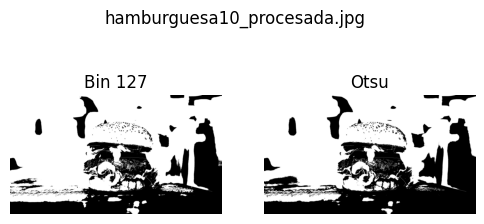

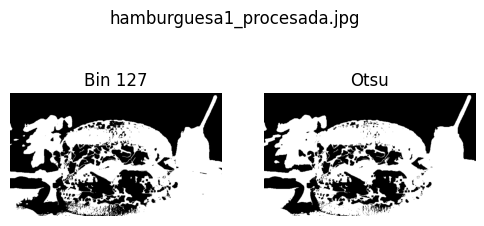

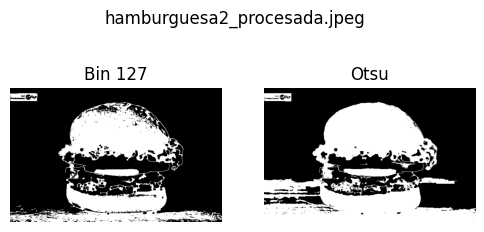

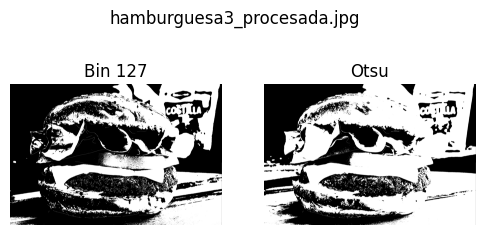

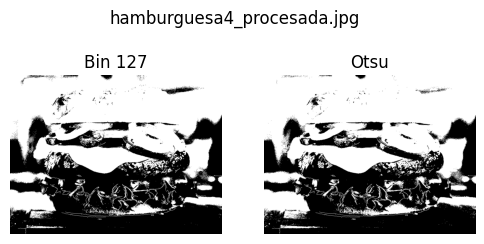

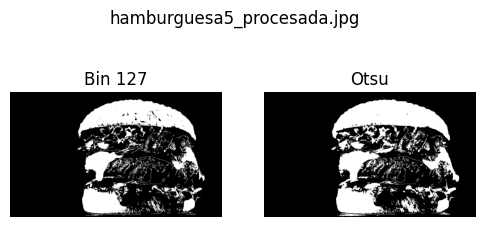

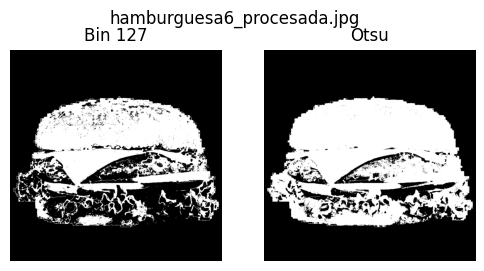

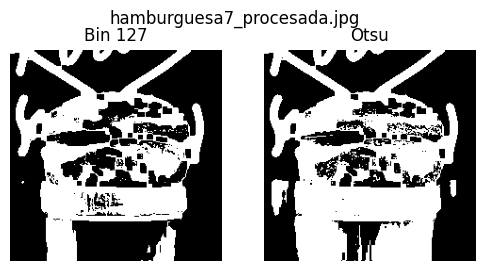

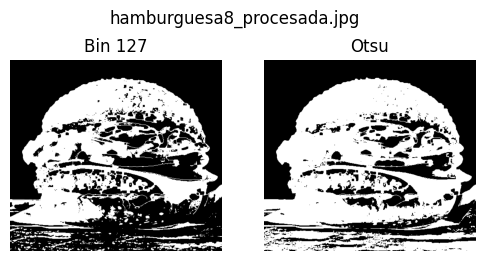

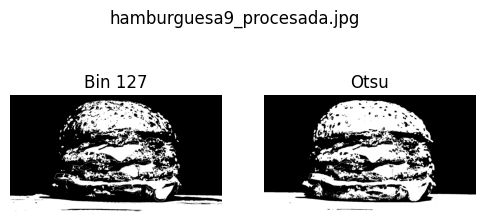

Distancias Hu (127 vs Otsu):

DISTANCIAS EUCLIDIANAS - Momentos Hu127

Matriz de distancias euclidianas (Hu 127):
                             hamburguesa10_procesada.jpg  \
hamburguesa10_procesada.jpg                     0.000000   
hamburguesa1_procesada.jpg                      0.000364   
hamburguesa2_procesada.jpeg                     0.000287   
hamburguesa3_procesada.jpg                      0.000320   
hamburguesa4_procesada.jpg                      0.000044   
hamburguesa5_procesada.jpg                      0.000729   
hamburguesa6_procesada.jpg                      0.000043   
hamburguesa7_procesada.jpg                      0.000196   
hamburguesa8_procesada.jpg                      0.000108   
hamburguesa9_procesada.jpg                      0.000635   

                             hamburguesa1_procesada.jpg  \
hamburguesa10_procesada.jpg                    0.000364   
hamburguesa1_procesada.jpg                     0.000000   
hamburguesa2_procesada.jpeg                    0

,Imagen,Dist_127_vs_Otsu
0,hamburguesa10_procesada.jpg,0.000059
1,hamburguesa1_procesada.jpg,0.000116
2,hamburguesa2_procesada.jpeg,0.000144
3,hamburguesa3_procesada.jpg,0.000310
4,hamburguesa4_procesada.jpg,0.000031
5,hamburguesa5_procesada.jpg,0.000279
6,hamburguesa6_procesada.jpg,0.000188
7,hamburguesa7_procesada.jpg,0.000241
8,hamburguesa8_procesada.jpg,0.000234
9,hamburguesa9_procesada.jpg,0.000330


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

IMAGES_DIR = Path('imagenes_preprocesadas')
image_paths = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')])

rows = []
for img_path in image_paths:
    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"No se pudo leer {img_path.name}")
        continue

    # Hu 127
    _, binary_127 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
    hu2 = cv2.HuMoments(cv2.moments(binary_127)).flatten()

    # Hu Otsu
    _, binary_otsu = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    hu3 = cv2.HuMoments(cv2.moments(binary_otsu)).flatten()

    dist23 = float(np.linalg.norm(hu2 - hu3))

    rows.append({'Imagen': img_path.name, **{f'Hu127_{i+1}': float(hu2[i]) for i in range(7)},
                 **{f'HuOtsu_{i+1}': float(hu3[i]) for i in range(7)}, 'Dist_127_vs_Otsu': dist23})

    # Visual rápido
    plt.figure(figsize=(6,3))
    plt.suptitle(img_path.name)
    plt.subplot(1,2,1); plt.imshow(binary_127, cmap='gray'); plt.title('Bin 127'); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(binary_otsu, cmap='gray'); plt.title('Otsu'); plt.axis('off')
    plt.show()

hu_df_127_vs_otsu = pd.DataFrame(rows)
print('Distancias Hu (127 vs Otsu):')

# Calcular distancias euclidianas usando Hu127
print("\n" + "="*60)
print("DISTANCIAS EUCLIDIANAS - Momentos Hu127")
print("="*60)

# Extraer características Hu127
feature_cols = [f'Hu127_{i+1}' for i in range(7)]
features = hu_df_127_vs_otsu[feature_cols].values
image_names = hu_df_127_vs_otsu['Imagen'].values

# Matriz de distancias
n = len(features)
distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])

# Crear DataFrame de distancias
dist_df = pd.DataFrame(distance_matrix, 
                       index=image_names, 
                       columns=image_names)

print("\nMatriz de distancias euclidianas (Hu 127):")
print(dist_df)

# Análisis de similitud
indices = np.triu_indices(n, k=1)
pairs = [(image_names[i], image_names[j], distance_matrix[i, j]) 
         for i, j in zip(indices[0], indices[1])]
pairs_sorted = sorted(pairs, key=lambda x: x[2])

print("\n🟢 Top 5 pares MÁS SIMILARES:")
for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.6e}")

print("\n🔴 Top 5 pares MÁS DIFERENTES:")
for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.6e}")

hu_df_127_vs_otsu[['Imagen','Dist_127_vs_Otsu']]

In [7]:
import cv2
import numpy as np
from pathlib import Path
import pandas as pd

IMAGES_DIR = Path('imagenes_preprocesadas')
image_paths = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')])

hog = cv2.HOGDescriptor()

rows = []
for img_path in image_paths:
    gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        print(f"No se pudo leer {img_path.name}")
        continue
    # Asegurar tamaño mínimo para HOG por defecto (dependiendo del descriptor)
    # Si falla, redimensionar a 128x64 (tamaño típico para HOG de personas) sólo para extraer features
    try:
        feats = hog.compute(gray)
    except Exception:
        resized = cv2.resize(gray, (128, 64))
        feats = hog.compute(resized)
    rows.append({'Imagen': img_path.name, 'HOG_len': int(feats.size)})

hog_df = pd.DataFrame(rows)
print('Características HOG extraídas.')

# Nota: HOG produce vectores de características muy largos
# Para comparar, necesitamos extraer los descriptores completos
print("\n" + "="*60)
print("DISTANCIAS EUCLIDIANAS - Descriptores HOG")
print("="*60)

# Re-extraer descriptores HOG completos para comparación
# IMPORTANTE: Redimensionar todas las imágenes al mismo tamaño para que HOG sea comparable
TARGET_SIZE = (128, 128)  # Tamaño fijo para todas las imágenes

hog_descriptors = []
valid_images = []

for img_path in image_paths:
    gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        continue
    
    # Redimensionar TODAS las imágenes al mismo tamaño
    resized = cv2.resize(gray, TARGET_SIZE)
    
    try:
        feats = hog.compute(resized)
        hog_descriptors.append(feats.flatten())
        valid_images.append(img_path.name)
    except Exception as e:
        print(f"Error en {img_path.name}: {e}")
        continue

# Ahora todos los descriptores tienen el mismo tamaño
hog_descriptors = np.array(hog_descriptors)
print(f"Descriptores HOG: {hog_descriptors.shape}")

# Matriz de distancias
n = len(hog_descriptors)
distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = np.linalg.norm(hog_descriptors[i] - hog_descriptors[j])

# Crear DataFrame de distancias
dist_df = pd.DataFrame(distance_matrix, 
                       index=valid_images, 
                       columns=valid_images)

print("\nMatriz de distancias euclidianas (HOG):")
print(dist_df.round(2))

# Análisis de similitud
indices = np.triu_indices(n, k=1)
pairs = [(valid_images[i], valid_images[j], distance_matrix[i, j]) 
         for i, j in zip(indices[0], indices[1])]
pairs_sorted = sorted(pairs, key=lambda x: x[2])

print("\n🟢 Top 5 pares MÁS SIMILARES:")
for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.2f}")

print("\n🔴 Top 5 pares MÁS DIFERENTES:")
for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.2f}")

hog_df

Características HOG extraídas.

DISTANCIAS EUCLIDIANAS - Descriptores HOG
Descriptores HOG: (10, 34020)

Matriz de distancias euclidianas (HOG):
                             hamburguesa10_procesada.jpg  \
hamburguesa10_procesada.jpg                         0.00   
hamburguesa1_procesada.jpg                         21.84   
hamburguesa2_procesada.jpeg                        23.85   
hamburguesa3_procesada.jpg                         22.86   
hamburguesa4_procesada.jpg                         22.62   
hamburguesa5_procesada.jpg                         22.97   
hamburguesa6_procesada.jpg                         25.97   
hamburguesa7_procesada.jpg                         25.92   
hamburguesa8_procesada.jpg                         23.61   
hamburguesa9_procesada.jpg                         22.71   

                             hamburguesa1_procesada.jpg  \
hamburguesa10_procesada.jpg                       21.84   
hamburguesa1_procesada.jpg                         0.00   
hamburguesa2_proc

,Imagen,HOG_len
0,hamburguesa10_procesada.jpg,195218100
1,hamburguesa1_procesada.jpg,11022480
2,hamburguesa2_procesada.jpeg,10069920
3,hamburguesa3_procesada.jpg,418842900
4,hamburguesa4_procesada.jpg,26085780
5,hamburguesa5_procesada.jpg,39459420
6,hamburguesa6_procesada.jpg,49064400
7,hamburguesa7_procesada.jpg,1031940
8,hamburguesa8_procesada.jpg,10432800
9,hamburguesa9_procesada.jpg,43375500


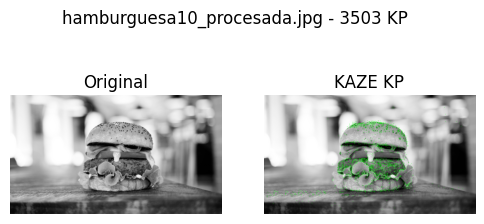

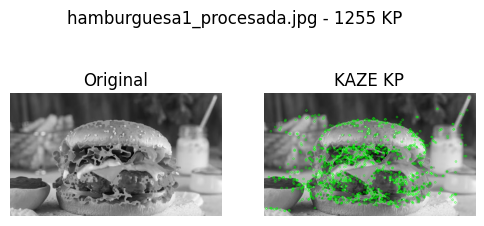

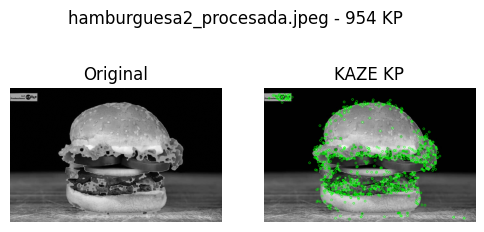

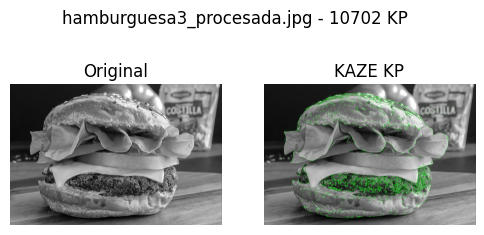

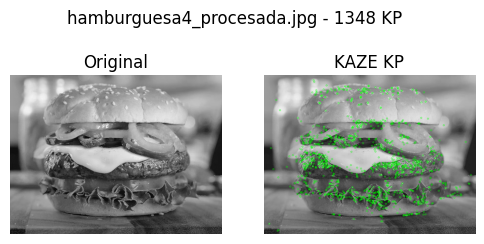

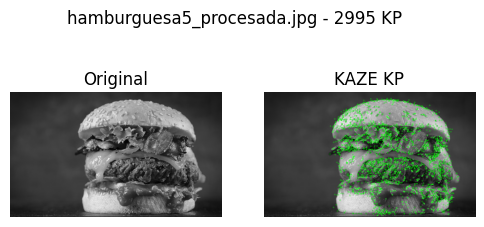

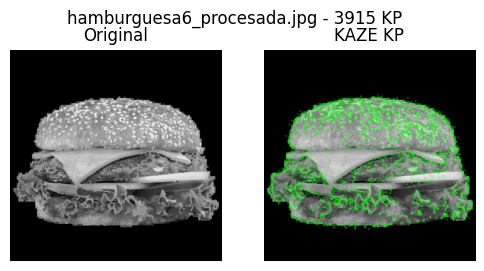

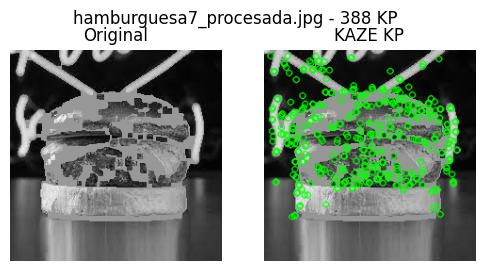

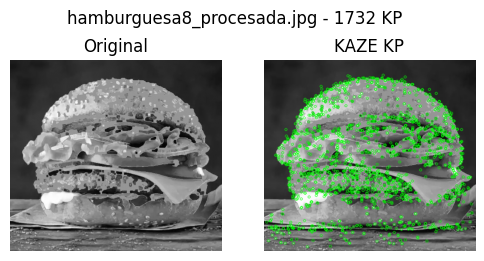

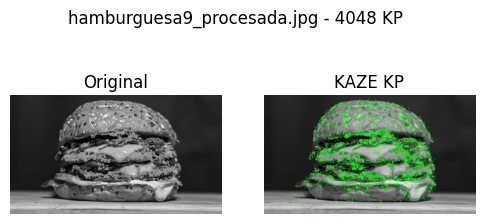

KAZE completado.

KAZE: 10 imágenes procesadas


,Imagen,Num_Keypoints,Descriptor_Dims,Total_Descriptors
0,hamburguesa10_procesada.jpg,3503,64,3503
1,hamburguesa1_procesada.jpg,1255,64,1255
2,hamburguesa2_procesada.jpeg,954,64,954
3,hamburguesa3_procesada.jpg,10702,64,10702
4,hamburguesa4_procesada.jpg,1348,64,1348
5,hamburguesa5_procesada.jpg,2995,64,2995
6,hamburguesa6_procesada.jpg,3915,64,3915
7,hamburguesa7_procesada.jpg,388,64,388
8,hamburguesa8_procesada.jpg,1732,64,1732
9,hamburguesa9_procesada.jpg,4048,64,4048


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

IMAGES_DIR = Path('imagenes_preprocesadas')
image_paths = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')])

kaze = cv2.KAZE_create()

# Almacenar datos para exportar
kaze_data = []

for img_path in image_paths:
    gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        print(f"No se pudo leer {img_path.name}")
        continue

    keypoints, descriptors = kaze.detectAndCompute(gray, None)
    img_kp = cv2.drawKeypoints(gray, keypoints, None, color=(0, 255, 0))
    
    # Guardar información
    kaze_data.append({
        'Imagen': img_path.name,
        'Num_Keypoints': len(keypoints),
        'Descriptor_Dims': descriptors.shape[1] if descriptors is not None else 0,
        'Total_Descriptors': descriptors.shape[0] if descriptors is not None else 0
    })

    plt.figure(figsize=(6,3))
    plt.suptitle(f"{img_path.name} - {len(keypoints)} KP")
    plt.subplot(1,2,1); plt.imshow(gray, cmap='gray'); plt.title('Original'); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(img_kp); plt.title('KAZE KP'); plt.axis('off')
    plt.show()

print('KAZE completado.')

# Crear DataFrame
kaze_df = pd.DataFrame(kaze_data)
print(f"\nKAZE: {len(kaze_df)} imágenes procesadas")
kaze_df

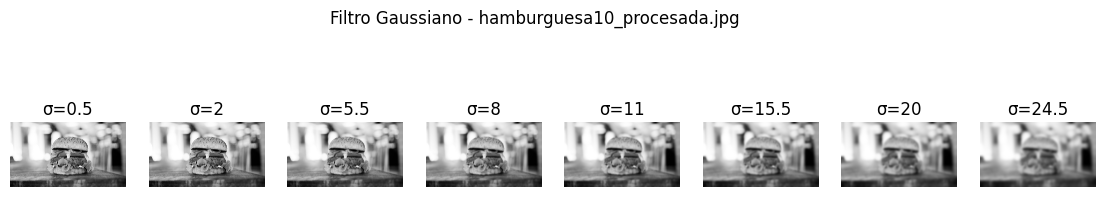

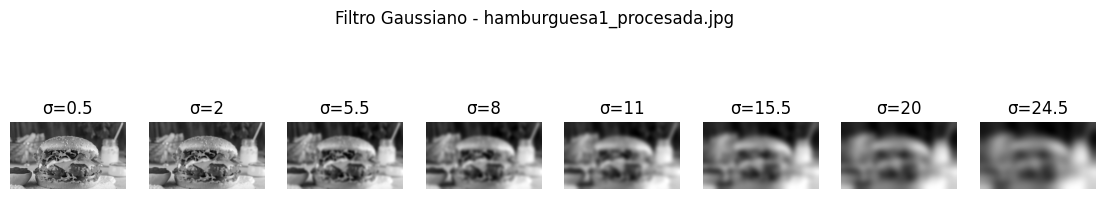

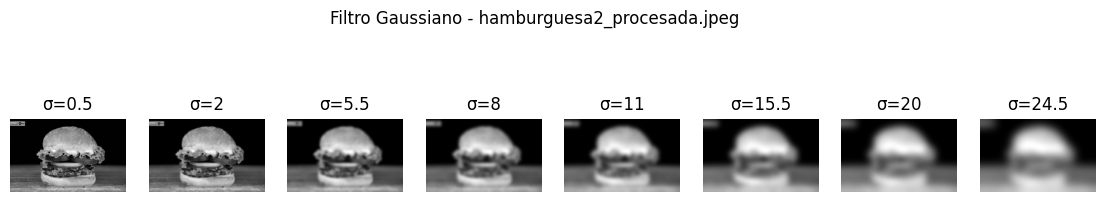

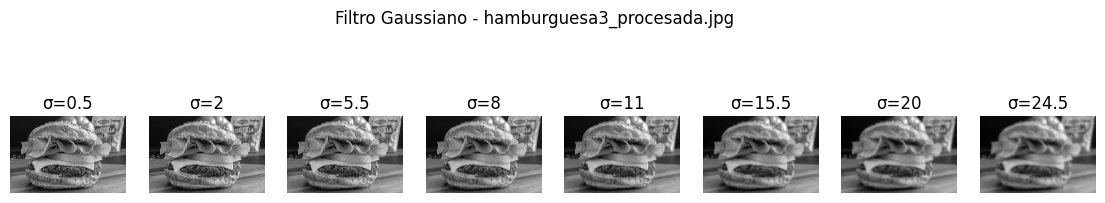

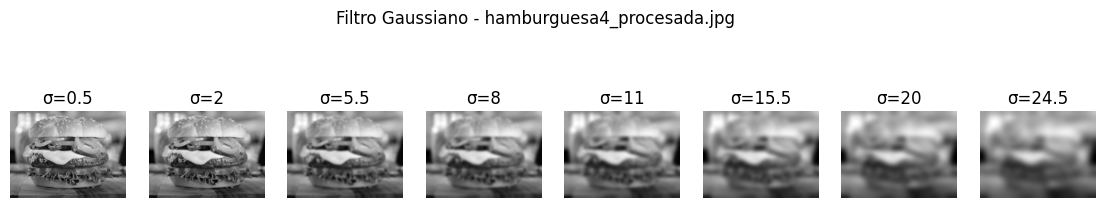

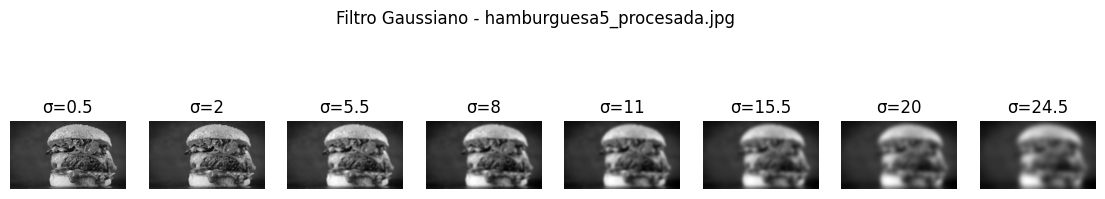

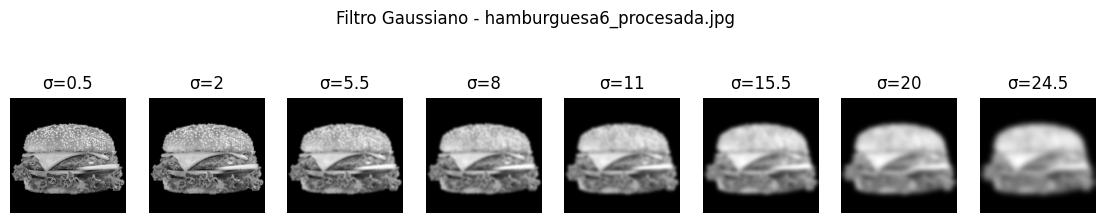

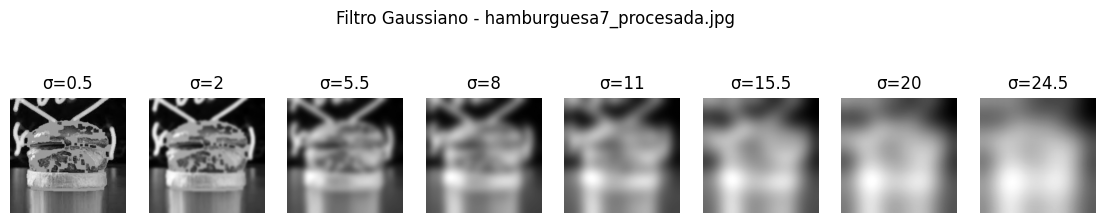

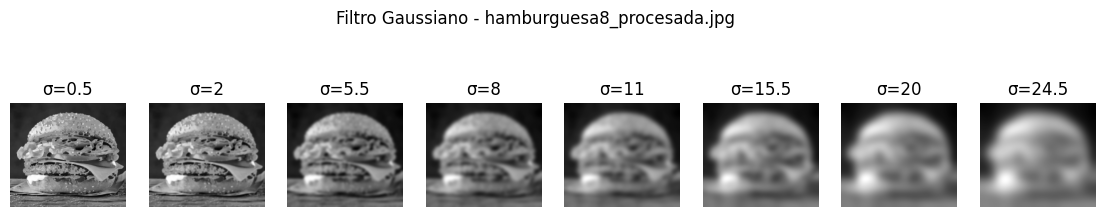

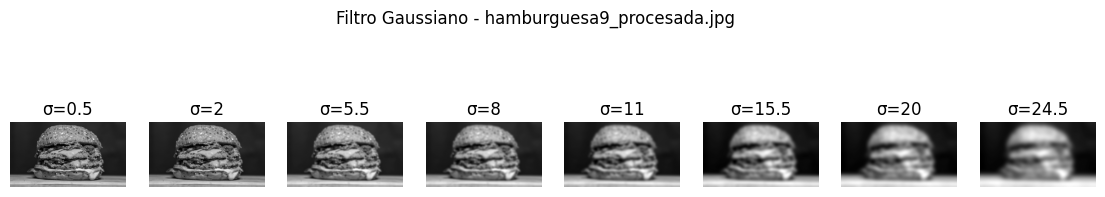

Filtros gaussianos aplicados.

DISTANCIAS EUCLIDIANAS - Histogramas de Filtros Gaussianos

Matriz de distancias euclidianas (Histogramas Gaussianos σ=11):
                             hamburguesa10_procesada.jpg  \
hamburguesa10_procesada.jpg                       0.0000   
hamburguesa1_procesada.jpg                        0.0524   
hamburguesa2_procesada.jpeg                       0.2699   
hamburguesa3_procesada.jpg                        0.0546   
hamburguesa4_procesada.jpg                        0.0536   
hamburguesa5_procesada.jpg                        0.0970   
hamburguesa6_procesada.jpg                        0.4578   
hamburguesa7_procesada.jpg                        0.0734   
hamburguesa8_procesada.jpg                        0.0687   
hamburguesa9_procesada.jpg                        0.1001   

                             hamburguesa1_procesada.jpg  \
hamburguesa10_procesada.jpg                      0.0524   
hamburguesa1_procesada.jpg                       0.0000   
hamburg

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path('imagenes_preprocesadas')
image_paths = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')])

sigma_values = [0.5, 2, 5.5, 8, 11, 15.5, 20, 24.5]

for img_path in image_paths:
    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"No se pudo leer {img_path.name}")
        continue

    plt.figure(figsize=(14, 3))
    plt.suptitle(f"Filtro Gaussiano - {img_path.name}")
    for i, sigma in enumerate(sigma_values):
        ksize = int(2 * (sigma * 3) + 1)
        ksize = ksize + 1 if ksize % 2 == 0 else ksize
        filtered_image = cv2.GaussianBlur(image, (ksize, ksize), sigma)
        plt.subplot(1, len(sigma_values), i + 1)
        plt.imshow(filtered_image, cmap='gray')
        plt.title(f'σ={sigma}')
        plt.axis('off')
    plt.show()

print('Filtros gaussianos aplicados.')

# Calcular distancias euclidianas entre imágenes usando descriptores de histograma
print("\n" + "="*60)
print("DISTANCIAS EUCLIDIANAS - Histogramas de Filtros Gaussianos")
print("="*60)

# Extraer histogramas de cada imagen con sigma medio (índice 4 = sigma 11)
import pandas as pd
gaussian_data = []
gaussian_features = []

for img_path in image_paths:
    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        continue
    
    # Aplicar filtro gaussiano con sigma intermedio
    sigma = 11
    ksize = int(2 * (sigma * 3) + 1)
    ksize = ksize + 1 if ksize % 2 == 0 else ksize
    filtered_image = cv2.GaussianBlur(image, (ksize, ksize), sigma)
    
    # Calcular histograma
    hist, _ = np.histogram(filtered_image.flatten(), bins=256, range=(0, 256))
    hist = hist.astype(float)
    hist /= hist.sum()  # Normalizar
    
    gaussian_features.append(hist)
    gaussian_data.append({
        'Imagen': img_path.name,
        'Media_Filtrada': float(np.mean(filtered_image)),
        'Std_Filtrada': float(np.std(filtered_image))
    })

gaussian_df = pd.DataFrame(gaussian_data)
features = np.array(gaussian_features)
image_names = gaussian_df['Imagen'].values

# Matriz de distancias
n = len(features)
distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])

# Crear DataFrame de distancias
dist_df = pd.DataFrame(distance_matrix, 
                       index=image_names, 
                       columns=image_names)

print("\nMatriz de distancias euclidianas (Histogramas Gaussianos σ=11):")
print(dist_df.round(4))

# Análisis de similitud
indices = np.triu_indices(n, k=1)
pairs = [(image_names[i], image_names[j], distance_matrix[i, j]) 
         for i, j in zip(indices[0], indices[1])]
pairs_sorted = sorted(pairs, key=lambda x: x[2])

print("\n🟢 Top 5 pares MÁS SIMILARES:")
for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.6f}")

print("\n🔴 Top 5 pares MÁS DIFERENTES:")
for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.6f}")

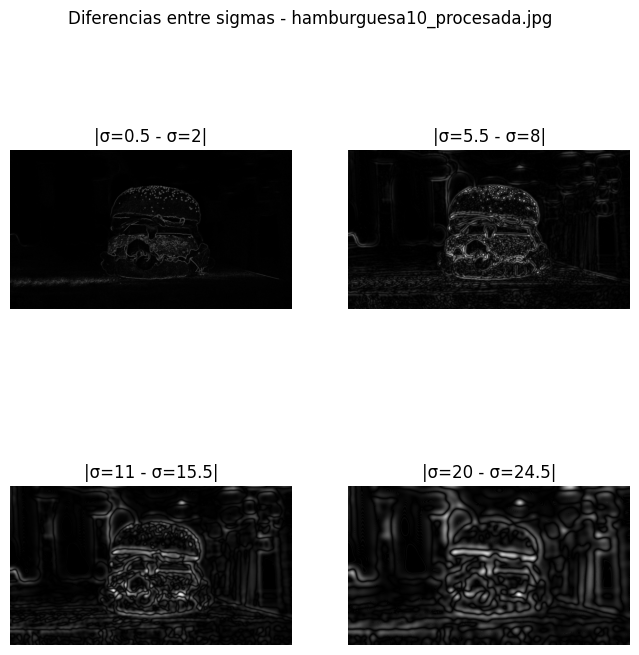

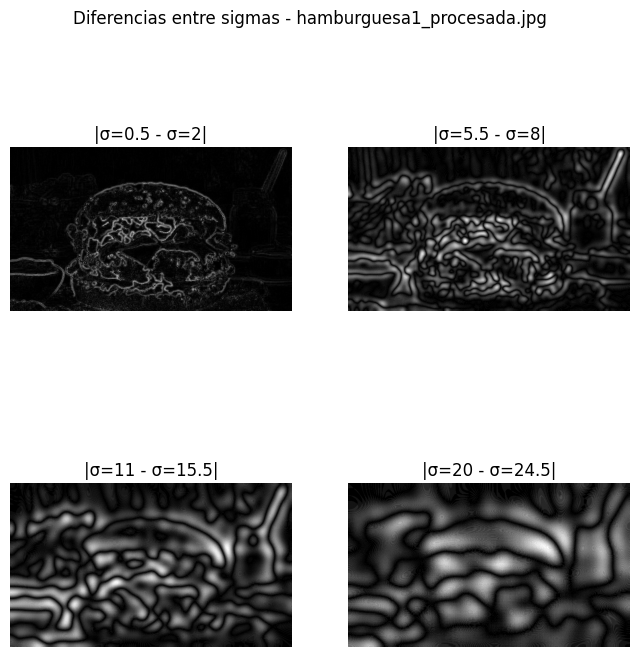

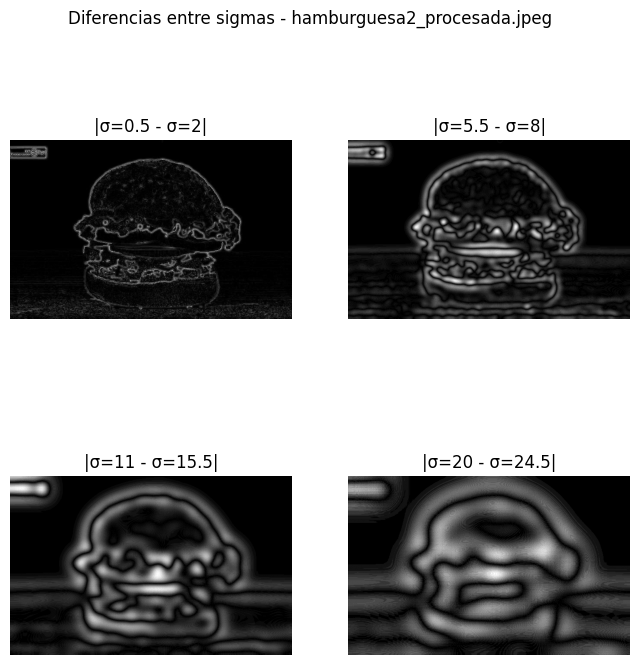

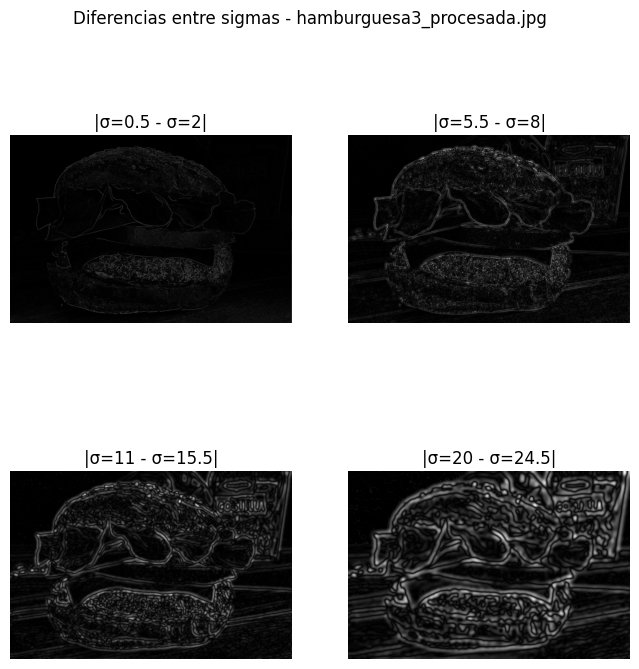

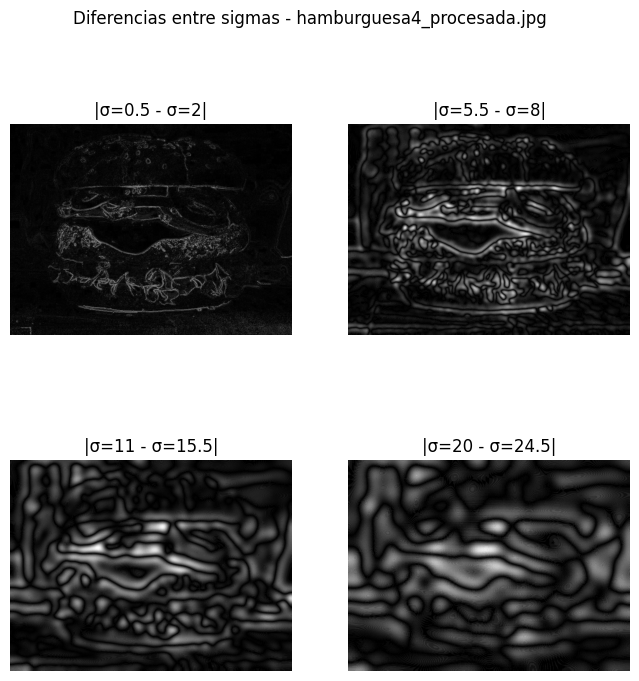

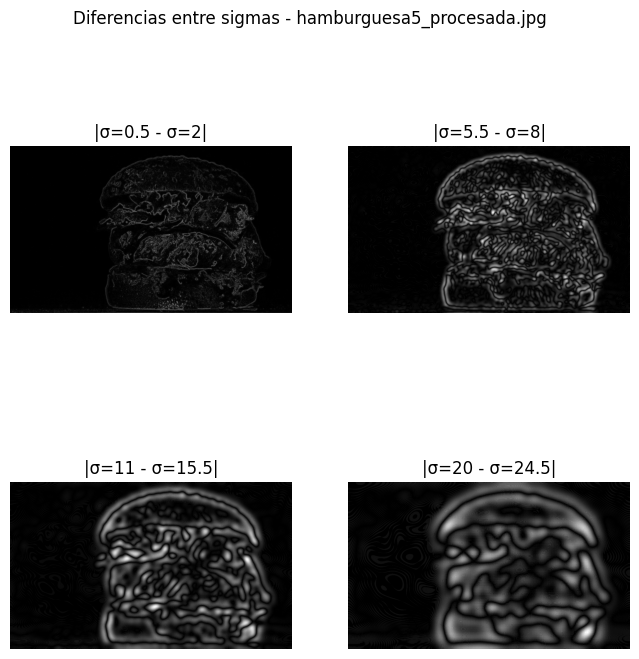

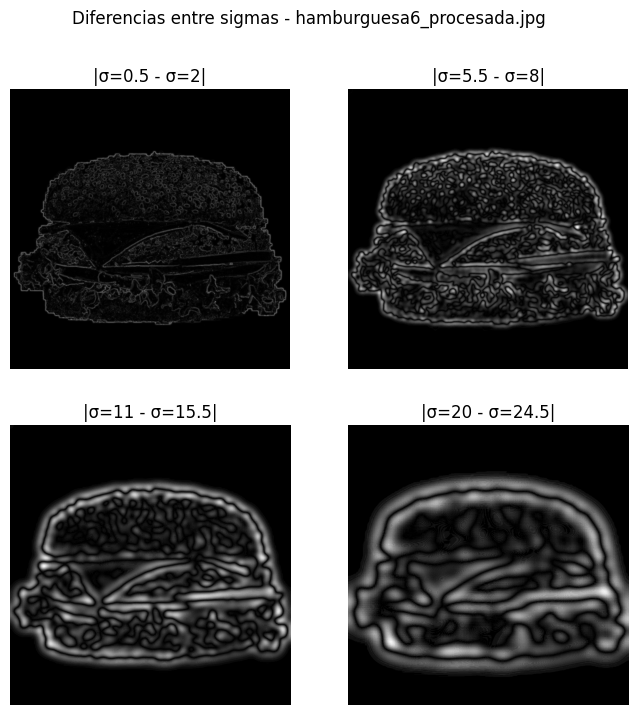

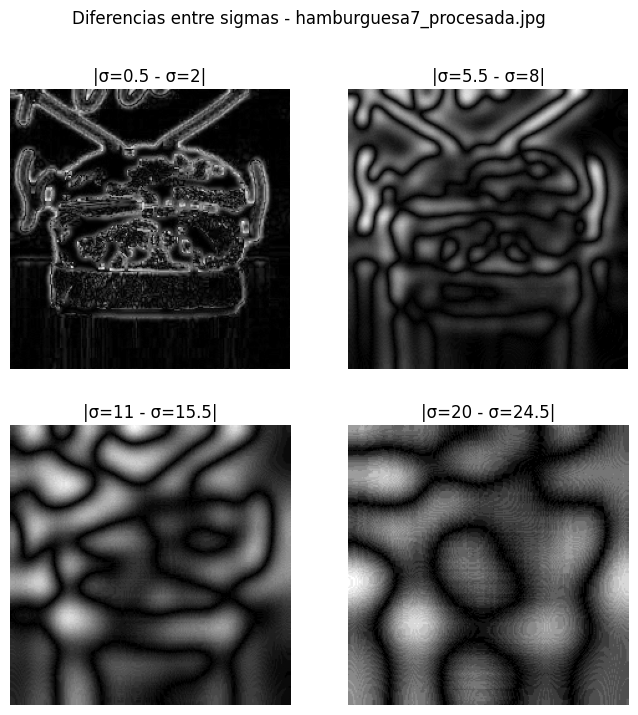

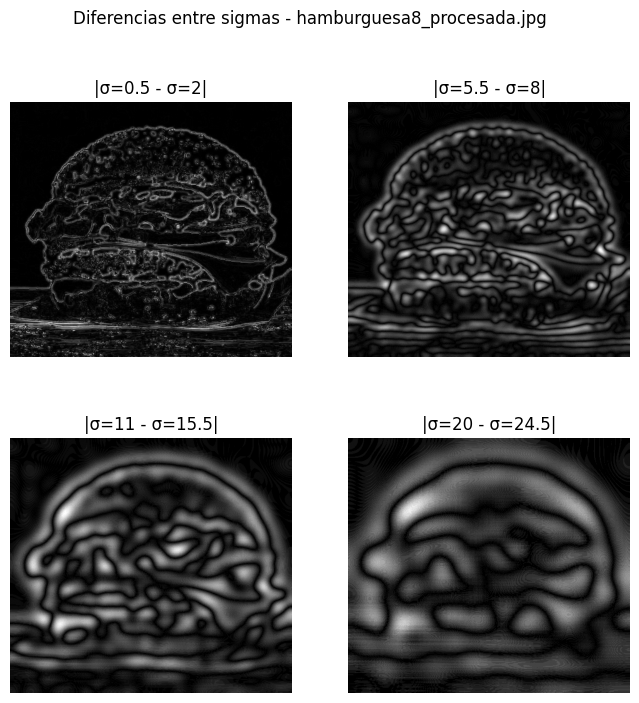

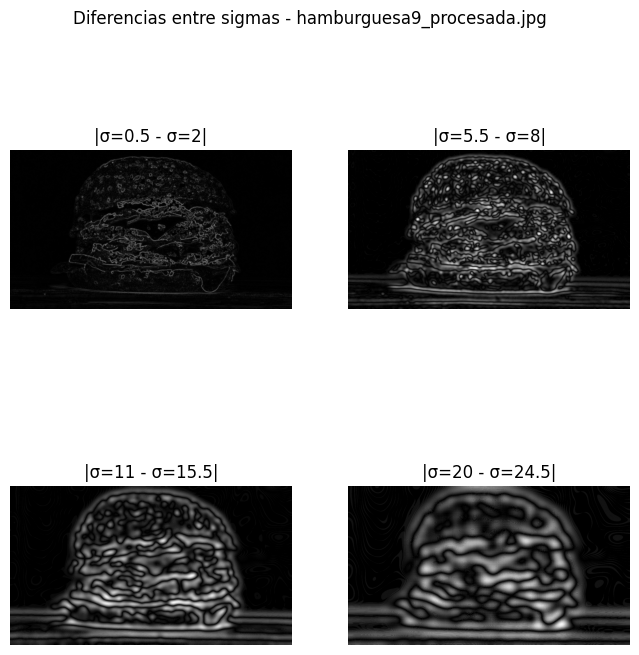

Diferencias entre imágenes gaussianas mostradas.

DISTANCIAS EUCLIDIANAS - Diferencias entre Sigmas

Matriz de distancias euclidianas (Diferencias entre sigmas):
                             hamburguesa10_procesada.jpg  \
hamburguesa10_procesada.jpg                       0.0000   
hamburguesa1_procesada.jpg                        4.0866   
hamburguesa2_procesada.jpeg                       3.6294   
hamburguesa3_procesada.jpg                        0.9265   
hamburguesa4_procesada.jpg                        3.4005   
hamburguesa5_procesada.jpg                        2.4638   
hamburguesa6_procesada.jpg                        2.7870   
hamburguesa7_procesada.jpg                       10.1596   
hamburguesa8_procesada.jpg                        6.3930   
hamburguesa9_procesada.jpg                        3.3559   

                             hamburguesa1_procesada.jpg  \
hamburguesa10_procesada.jpg                      4.0866   
hamburguesa1_procesada.jpg                       0.0000   


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path('imagenes_preprocesadas')
image_paths = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')])

sigma_values = [0.5, 2, 5.5, 8, 11, 15.5, 20, 24.5]

for img_path in image_paths:
    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"No se pudo leer {img_path.name}")
        continue

    filtered_images = {}
    for sigma in sigma_values:
        ksize = int(2 * (sigma * 3) + 1)
        ksize = ksize + 1 if ksize % 2 == 0 else ksize
        filtered_images[sigma] = cv2.GaussianBlur(image, (ksize, ksize), sigma)

    # Mostrar diferencias para unas pocas parejas para no saturar
    pairs = [(0.5, 2), (5.5, 8), (11, 15.5), (20, 24.5)]
    plt.figure(figsize=(8, 8))
    plt.suptitle(f"Diferencias entre sigmas - {img_path.name}")
    for i, (s1, s2) in enumerate(pairs, start=1):
        diff = cv2.absdiff(filtered_images[s1], filtered_images[s2])
        plt.subplot(2, 2, i)
        plt.imshow(diff, cmap='gray')
        plt.title(f'|σ={s1} - σ={s2}|')
        plt.axis('off')
    plt.show()

print('Diferencias entre imágenes gaussianas mostradas.')

# Calcular distancias euclidianas usando características de diferencias
print("\n" + "="*60)
print("DISTANCIAS EUCLIDIANAS - Diferencias entre Sigmas")
print("="*60)

import pandas as pd
diff_data = []
diff_features = []

for img_path in image_paths:
    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        continue
    
    # Calcular filtros con diferentes sigmas
    filtered_images = {}
    for sigma in sigma_values:
        ksize = int(2 * (sigma * 3) + 1)
        ksize = ksize + 1 if ksize % 2 == 0 else ksize
        filtered_images[sigma] = cv2.GaussianBlur(image, (ksize, ksize), sigma)
    
    # Calcular diferencias entre pares de sigmas
    pairs = [(0.5, 2), (5.5, 8), (11, 15.5), (20, 24.5)]
    diff_means = []
    for s1, s2 in pairs:
        diff = cv2.absdiff(filtered_images[s1], filtered_images[s2])
        diff_means.append(float(np.mean(diff)))
    
    diff_features.append(diff_means)
    diff_data.append({
        'Imagen': img_path.name,
        'Diff_0.5-2': diff_means[0],
        'Diff_5.5-8': diff_means[1],
        'Diff_11-15.5': diff_means[2],
        'Diff_20-24.5': diff_means[3]
    })

diff_df = pd.DataFrame(diff_data)
features = np.array(diff_features)
image_names = diff_df['Imagen'].values

# Matriz de distancias
n = len(features)
distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])

# Crear DataFrame de distancias
dist_df = pd.DataFrame(distance_matrix, 
                       index=image_names, 
                       columns=image_names)

print("\nMatriz de distancias euclidianas (Diferencias entre sigmas):")
print(dist_df.round(4))

# Análisis de similitud
indices = np.triu_indices(n, k=1)
pairs_list = [(image_names[i], image_names[j], distance_matrix[i, j]) 
              for i, j in zip(indices[0], indices[1])]
pairs_sorted = sorted(pairs_list, key=lambda x: x[2])

print("\n🟢 Top 5 pares MÁS SIMILARES:")
for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.6f}")

print("\n🔴 Top 5 pares MÁS DIFERENTES:")
for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.6f}")

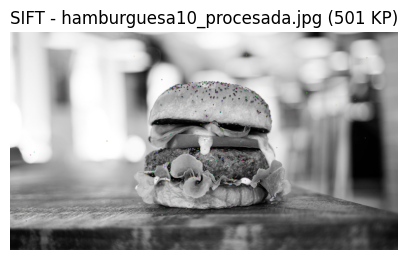

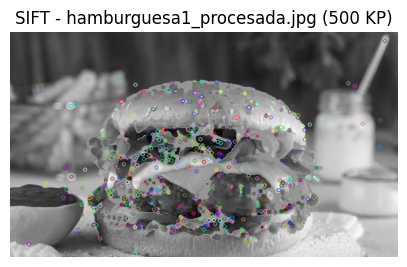

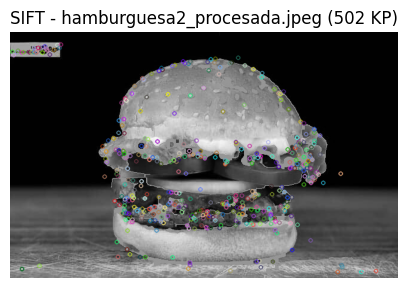

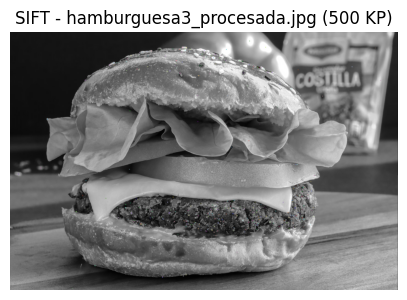

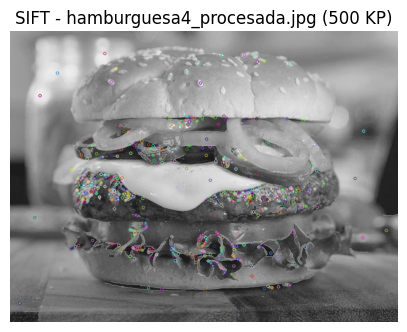

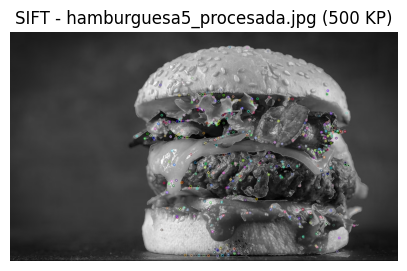

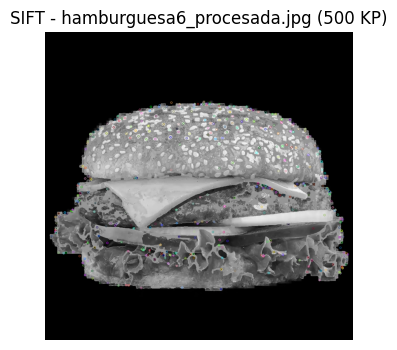

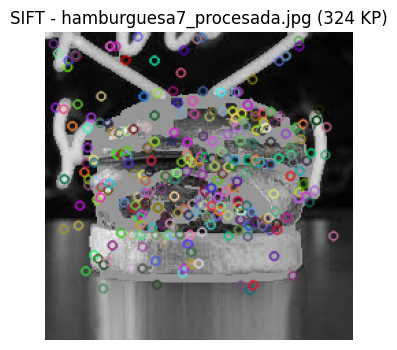

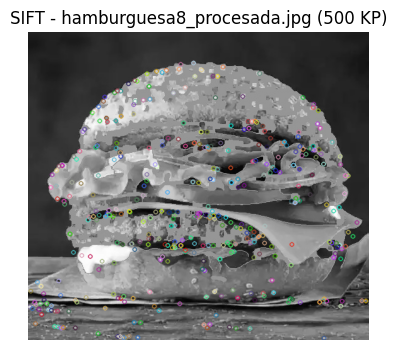

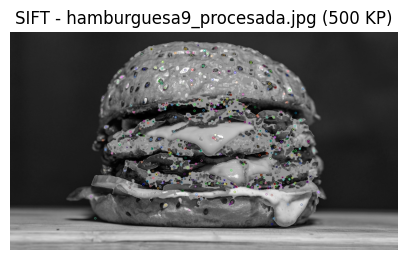

No se encontró la imagen de referencia 'cereal*.png'.

DISTANCIAS EUCLIDIANAS - Descriptores SIFT

Matriz de distancias euclidianas (SIFT promedio descriptores):
                             hamburguesa10_procesada.jpg  \
hamburguesa10_procesada.jpg                       0.0000   
hamburguesa1_procesada.jpg                      143.9415   
hamburguesa2_procesada.jpeg                     151.5501   
hamburguesa3_procesada.jpg                      179.3102   
hamburguesa4_procesada.jpg                      147.3069   
hamburguesa5_procesada.jpg                      177.5609   
hamburguesa6_procesada.jpg                      189.1068   
hamburguesa7_procesada.jpg                      138.9138   
hamburguesa8_procesada.jpg                      144.9202   
hamburguesa9_procesada.jpg                      122.5205   

                             hamburguesa1_procesada.jpg  \
hamburguesa10_procesada.jpg                    143.9415   
hamburguesa1_procesada.jpg                       0.0000   


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path('imagenes_preprocesadas')
image_paths = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')])

# SIFT en cada imagen
sift = cv2.SIFT_create(nfeatures=500)
for img_path in image_paths:
    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"No se pudo leer {img_path.name}")
        continue
    keypoints, descriptors = sift.detectAndCompute(image, None)
    image_with_keypoints = cv2.drawKeypoints(image, keypoints, None)
    plt.figure(figsize=(5,4))
    plt.title(f"SIFT - {img_path.name} ({len(keypoints)} KP)")
    plt.imshow(image_with_keypoints)
    plt.axis('off')
    plt.show()

# Matching: cereal vs cada otra imagen
ref_path = next((p for p in image_paths if p.name.lower().startswith('cereal')), None)
if ref_path is not None:
    img_ref = cv2.imread(str(ref_path), cv2.IMREAD_GRAYSCALE)
    kp_ref, desc_ref = sift.detectAndCompute(img_ref, None)
    bf = cv2.BFMatcher()
    for img_path in image_paths:
        if img_path == ref_path:
            continue
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        kp, desc = sift.detectAndCompute(img, None)
        if desc_ref is None or desc is None:
            print(f"Sin descriptores suficientes para {img_path.name}")
            continue
        matches = bf.knnMatch(desc_ref, desc, k=2)
        good = [m for m, n in matches if m.distance < 0.75 * n.distance]
        if img_path.name.lower().startswith('barritas'):
            img_matches = cv2.drawMatches(img_ref, kp_ref, img, kp, good, None,
                                          flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
            plt.figure(figsize=(8,4))
            plt.title(f"Coincidencias SIFT: cereal vs {img_path.name} ({len(good)} buenas)")
            plt.imshow(img_matches)
            plt.axis('off')
            plt.show()
        else:
            print(f"cereal vs {img_path.name}: {len(good)} coincidencias buenas, distancia media = {np.mean([m.distance for m in good]) if good else np.nan}")
else:
    print("No se encontró la imagen de referencia 'cereal*.png'.")

# Calcular distancias euclidianas usando descriptores SIFT
print("\n" + "="*60)
print("DISTANCIAS EUCLIDIANAS - Descriptores SIFT")
print("="*60)

import pandas as pd
sift_data = []
sift_descriptors = []

for img_path in image_paths:
    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        continue
    keypoints, descriptors = sift.detectAndCompute(image, None)
    
    if descriptors is not None and len(descriptors) > 0:
        # Usar promedio de descriptores como feature vector
        avg_descriptor = np.mean(descriptors, axis=0)
        sift_descriptors.append(avg_descriptor)
    else:
        sift_descriptors.append(np.zeros(128))  # SIFT usa 128 dimensiones
    
    sift_data.append({
        'Imagen': img_path.name,
        'Num_Keypoints': len(keypoints) if keypoints else 0,
        'Num_Descriptores': len(descriptors) if descriptors is not None else 0
    })

sift_df = pd.DataFrame(sift_data)
features = np.array(sift_descriptors)
image_names = sift_df['Imagen'].values

# Matriz de distancias
n = len(features)
distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])

# Crear DataFrame de distancias
dist_df = pd.DataFrame(distance_matrix, 
                       index=image_names, 
                       columns=image_names)

print("\nMatriz de distancias euclidianas (SIFT promedio descriptores):")
print(dist_df.round(4))

# Análisis de similitud
indices = np.triu_indices(n, k=1)
pairs_list = [(image_names[i], image_names[j], distance_matrix[i, j]) 
              for i, j in zip(indices[0], indices[1])]
pairs_sorted = sorted(pairs_list, key=lambda x: x[2])

print("\n🟢 Top 5 pares MÁS SIMILARES:")
for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.4f}")

print("\n🔴 Top 5 pares MÁS DIFERENTES:")
for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.4f}")

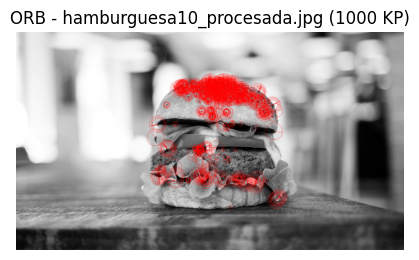

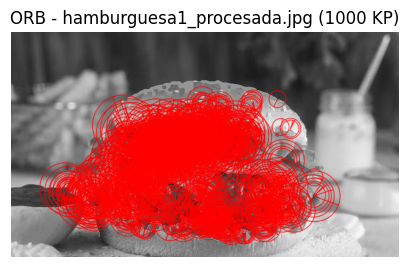

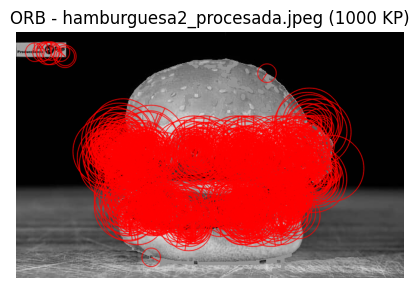

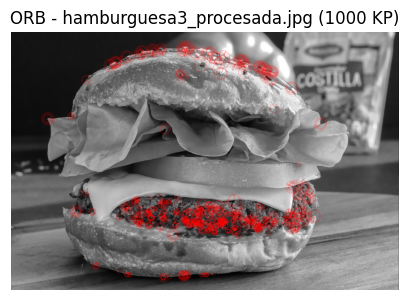

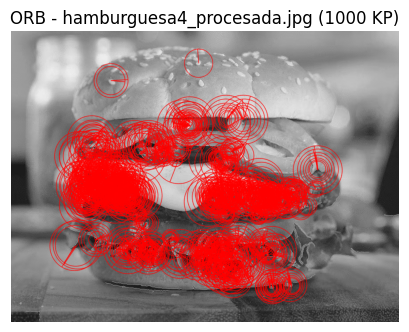

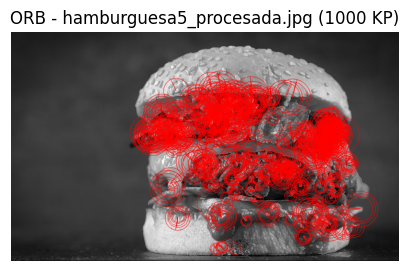

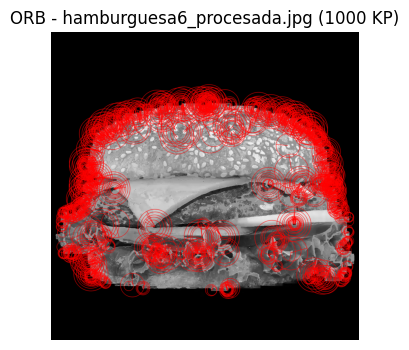

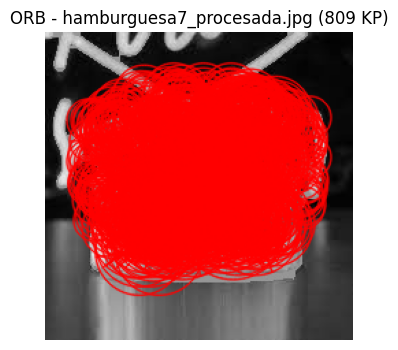

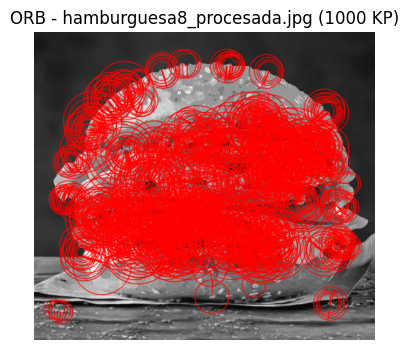

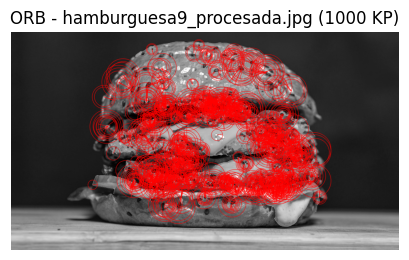

ORB completado.

DISTANCIAS EUCLIDIANAS - Descriptores ORB

Matriz de distancias euclidianas (ORB promedio descriptores):
                             hamburguesa10_procesada.jpg  \
hamburguesa10_procesada.jpg                       0.0000   
hamburguesa1_procesada.jpg                      106.5122   
hamburguesa2_procesada.jpeg                     141.6419   
hamburguesa3_procesada.jpg                      168.7675   
hamburguesa4_procesada.jpg                      140.2408   
hamburguesa5_procesada.jpg                      169.0390   
hamburguesa6_procesada.jpg                      176.4026   
hamburguesa7_procesada.jpg                      109.6400   
hamburguesa8_procesada.jpg                      100.1787   
hamburguesa9_procesada.jpg                      129.2833   

                             hamburguesa1_procesada.jpg  \
hamburguesa10_procesada.jpg                    106.5122   
hamburguesa1_procesada.jpg                       0.0000   
hamburguesa2_procesada.jpeg             

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path('imagenes_preprocesadas')
image_paths = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')])

orb = cv2.ORB_create(nfeatures=1000)

for img_path in image_paths:
    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"No se pudo leer {img_path.name}")
        continue
    keypoints, descriptors = orb.detectAndCompute(image, None)
    image_with_keypoints = cv2.drawKeypoints(image, keypoints, None, color=(255, 0, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    plt.figure(figsize=(5,4))
    plt.title(f"ORB - {img_path.name} ({len(keypoints)} KP)")
    plt.imshow(image_with_keypoints)
    plt.axis('off')
    plt.show()

    # Guardar si se desea
    # cv2.imwrite(f'orb_kp_{img_path.stem}.jpg', image_with_keypoints)

print('ORB completado.')

# Calcular distancias euclidianas usando descriptores ORB
print("\n" + "="*60)
print("DISTANCIAS EUCLIDIANAS - Descriptores ORB")
print("="*60)

import pandas as pd
orb_data = []
orb_descriptors = []

for img_path in image_paths:
    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        continue
    keypoints, descriptors = orb.detectAndCompute(image, None)
    
    if descriptors is not None and len(descriptors) > 0:
        # Convertir descriptores binarios a float y promediar
        desc_float = descriptors.astype(np.float32)
        avg_descriptor = np.mean(desc_float, axis=0)
        orb_descriptors.append(avg_descriptor)
    else:
        orb_descriptors.append(np.zeros(32))  # ORB usa 32 bytes (256 bits)
    
    orb_data.append({
        'Imagen': img_path.name,
        'Num_Keypoints': len(keypoints) if keypoints else 0,
        'Num_Descriptores': len(descriptors) if descriptors is not None else 0
    })

orb_df = pd.DataFrame(orb_data)
features = np.array(orb_descriptors)
image_names = orb_df['Imagen'].values

# Matriz de distancias
n = len(features)
distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])

# Crear DataFrame de distancias
dist_df = pd.DataFrame(distance_matrix, 
                       index=image_names, 
                       columns=image_names)

print("\nMatriz de distancias euclidianas (ORB promedio descriptores):")
print(dist_df.round(4))

# Análisis de similitud
indices = np.triu_indices(n, k=1)
pairs_list = [(image_names[i], image_names[j], distance_matrix[i, j]) 
              for i, j in zip(indices[0], indices[1])]
pairs_sorted = sorted(pairs_list, key=lambda x: x[2])

print("\n🟢 Top 5 pares MÁS SIMILARES:")
for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.4f}")

print("\n🔴 Top 5 pares MÁS DIFERENTES:")
for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.4f}")

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path('imagenes_preprocesadas')
image_paths = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')])

# Buscar hamburguesa como referencia
ref_path = next((p for p in image_paths if p.name.lower().startswith('hamburguesa')), None)
if ref_path is None:
    print("No se encontró 'hamburguesa' como referencia")
else:
    ref = cv2.imread(str(ref_path), cv2.IMREAD_GRAYSCALE)
    for img_path in image_paths:
        if img_path == ref_path:
            continue
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        # Redimensionar a la forma de referencia si es distinto tamaño
        if img.shape != ref.shape:
            img = cv2.resize(img, (ref.shape[1], ref.shape[0]))
        flow = cv2.calcOpticalFlowFarneback(ref, img, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
        hsv = np.zeros((*ref.shape, 3), dtype=np.float32)
        hsv[..., 1] = 255
        hsv[..., 0] = ang * 180 / np.pi / 2
        hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
        flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

        if img_path.name.lower().startswith('barritas'):
            plt.figure(figsize=(5,4))
            plt.title(f'Optical Flow: hamburguesa vs {img_path.name}')
            plt.imshow(flow_rgb.astype(np.uint8))
            plt.axis('off')
            plt.show()

    print('Flujo óptico calculado contra hamburguesa.')

# Calcular distancias euclidianas usando características de flujo óptico
print("\n" + "="*60)
print("DISTANCIAS EUCLIDIANAS - Flujo Óptico")
print("="*60)

import pandas as pd
flow_data = []
flow_features = []

# Usar hamburguesa como referencia
ref_path = next((p for p in image_paths if p.name.lower().startswith('hamburguesa')), None)
if ref_path is not None:
    ref = cv2.imread(str(ref_path), cv2.IMREAD_GRAYSCALE)
    
    for img_path in image_paths:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        
        # Redimensionar si es necesario
        if img.shape != ref.shape:
            img = cv2.resize(img, (ref.shape[1], ref.shape[0]))
        
        # Calcular flujo óptico
        flow = cv2.calcOpticalFlowFarneback(ref, img, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
        
        # Características de flujo
        flow_mean_mag = float(np.mean(mag))
        flow_std_mag = float(np.std(mag))
        flow_mean_ang = float(np.mean(ang))
        flow_std_ang = float(np.std(ang))
        
        flow_features.append([flow_mean_mag, flow_std_mag, flow_mean_ang, flow_std_ang])
        flow_data.append({
            'Imagen': img_path.name,
            'Flujo_Media_Mag': flow_mean_mag,
            'Flujo_Std_Mag': flow_std_mag,
            'Flujo_Media_Ang': flow_mean_ang,
            'Flujo_Std_Ang': flow_std_ang
        })
    
    flow_df = pd.DataFrame(flow_data)
    features = np.array(flow_features)
    image_names = flow_df['Imagen'].values
    
    # Matriz de distancias
    n = len(features)
    distance_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])
    
    # Crear DataFrame de distancias
    dist_df = pd.DataFrame(distance_matrix, 
                           index=image_names, 
                           columns=image_names)
    
    print("\nMatriz de distancias euclidianas (Flujo Óptico vs hamburguesa):")
    print(dist_df.round(4))
    
    # Análisis de similitud
    indices = np.triu_indices(n, k=1)
    pairs_list = [(image_names[i], image_names[j], distance_matrix[i, j]) 
                  for i, j in zip(indices[0], indices[1])]
    pairs_sorted = sorted(pairs_list, key=lambda x: x[2])
    
    print("\n🟢 Top 5 pares MÁS SIMILARES:")
    for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
        print(f"{i}. {img1} ↔ {img2}: {dist:.4f}")
    
    print("\n🔴 Top 5 pares MÁS DIFERENTES:")
    for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
        print(f"{i}. {img1} ↔ {img2}: {dist:.4f}")
else:
    print("No se encontró hamburguesa como referencia para el análisis de flujo.")

Flujo óptico calculado contra hamburguesa.

DISTANCIAS EUCLIDIANAS - Flujo Óptico

Matriz de distancias euclidianas (Flujo Óptico vs hamburguesa):
                             hamburguesa10_procesada.jpg  \
hamburguesa10_procesada.jpg                       0.0000   
hamburguesa1_procesada.jpg                        9.3038   
hamburguesa2_procesada.jpeg                      10.8879   
hamburguesa3_procesada.jpg                       11.3251   
hamburguesa4_procesada.jpg                        9.7953   
hamburguesa5_procesada.jpg                       12.1441   
hamburguesa6_procesada.jpg                       13.1290   
hamburguesa7_procesada.jpg                        8.9632   
hamburguesa8_procesada.jpg                       14.4048   
hamburguesa9_procesada.jpg                        9.8356   

                             hamburguesa1_procesada.jpg  \
hamburguesa10_procesada.jpg                      9.3038   
hamburguesa1_procesada.jpg                       0.0000   
hamburguesa2_pr

In [14]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path

IMAGES_DIR = Path('imagenes_preprocesadas')
image_paths = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')])

resultados = pd.DataFrame(columns=[
    'Imagen', 'SIFT_KP', 'ORB_KP', 'Coincidencias', 'Distancia_Promedio', 'Flujo_Magnitud', 'Flujo_Dirección'
])

sift = cv2.SIFT_create(nfeatures=500)
orb = cv2.ORB_create(nfeatures=1000)

# Referencia cereal
ref_path = next((p for p in image_paths if p.name.lower().startswith('cereal')), None)
ref_img = cv2.imread(str(ref_path), cv2.IMREAD_GRAYSCALE) if ref_path else None
kp_ref, desc_ref = sift.detectAndCompute(ref_img, None) if ref_img is not None else (None, None)
bf = cv2.BFMatcher()

for img_path in image_paths:
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    kp_sift, desc_sift = sift.detectAndCompute(img, None)
    sift_kp = len(kp_sift) if kp_sift is not None else 0

    kp_orb, desc_orb = orb.detectAndCompute(img, None)
    orb_kp = len(kp_orb) if kp_orb is not None else 0

    coincidencias = 0
    distancia_promedio = np.nan

    flujo_mag = np.nan
    flujo_ang = np.nan

    if ref_img is not None and img_path != ref_path and desc_ref is not None and desc_sift is not None and len(desc_sift) > 1:
        matches = bf.knnMatch(desc_sift, desc_ref, k=2)
        good = [m for m, n in matches if n is not None and m.distance < 0.75 * n.distance]
        coincidencias = len(good)
        distancia_promedio = float(np.mean([m.distance for m in good])) if good else np.nan

        # Optical Flow
        ref_resized = ref_img
        img_resized = img
        if img.shape != ref_img.shape:
            img_resized = cv2.resize(img, (ref_img.shape[1], ref_img.shape[0]))
        flow = cv2.calcOpticalFlowFarneback(ref_resized, img_resized, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
        flujo_mag = float(np.mean(mag))
        flujo_ang = float(np.mean(ang))

    resultados.loc[len(resultados)] = [img_path.name, sift_kp, orb_kp, coincidencias, distancia_promedio, flujo_mag, flujo_ang]

print('Métricas comparativas:')

# Calcular distancias euclidianas para métricas combinadas
print("\n" + "="*60)
print("DISTANCIAS EUCLIDIANAS - Métricas Combinadas (SIFT + ORB + Flujo)")
print("="*60)

# Extraer características numéricas (excluir NaN)
feature_cols = ['SIFT_KP', 'ORB_KP', 'Flujo_Magnitud']
features_raw = resultados[feature_cols].values
# Reemplazar NaN con 0
features = np.nan_to_num(features_raw, nan=0.0)
image_names = resultados['Imagen'].values

# Matriz de distancias
n = len(features)
distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])

# Crear DataFrame de distancias
dist_df = pd.DataFrame(distance_matrix, 
                       index=image_names, 
                       columns=image_names)

print("\nMatriz de distancias euclidianas (Métricas combinadas):")
print(dist_df.round(2))

# Análisis de similitud
indices = np.triu_indices(n, k=1)
pairs = [(image_names[i], image_names[j], distance_matrix[i, j]) 
         for i, j in zip(indices[0], indices[1])]
pairs_sorted = sorted(pairs, key=lambda x: x[2])

print("\n🟢 Top 5 pares MÁS SIMILARES:")
for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.2f}")

print("\n🔴 Top 5 pares MÁS DIFERENTES:")
for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
    print(f"{i}. {img1} ↔ {img2}: {dist:.2f}")

resultados

Métricas comparativas:

DISTANCIAS EUCLIDIANAS - Métricas Combinadas (SIFT + ORB + Flujo)

Matriz de distancias euclidianas (Métricas combinadas):
                             hamburguesa10_procesada.jpg  \
hamburguesa10_procesada.jpg                          0.0   
hamburguesa1_procesada.jpg                           1.0   
hamburguesa2_procesada.jpeg                          1.0   
hamburguesa3_procesada.jpg                           1.0   
hamburguesa4_procesada.jpg                           1.0   
hamburguesa5_procesada.jpg                           1.0   
hamburguesa6_procesada.jpg                           1.0   
hamburguesa7_procesada.jpg                         260.4   
hamburguesa8_procesada.jpg                           1.0   
hamburguesa9_procesada.jpg                           1.0   

                             hamburguesa1_procesada.jpg  \
hamburguesa10_procesada.jpg                        1.00   
hamburguesa1_procesada.jpg                         0.00   
hamburguesa2_pr

,Imagen,SIFT_KP,ORB_KP,Coincidencias,Distancia_Promedio,Flujo_Magnitud,Flujo_Dirección
0,hamburguesa10_procesada.jpg,501,1000,0,NaN,NaN,NaN
1,hamburguesa1_procesada.jpg,500,1000,0,NaN,NaN,NaN
2,hamburguesa2_procesada.jpeg,502,1000,0,NaN,NaN,NaN
3,hamburguesa3_procesada.jpg,500,1000,0,NaN,NaN,NaN
4,hamburguesa4_procesada.jpg,500,1000,0,NaN,NaN,NaN
5,hamburguesa5_procesada.jpg,500,1000,0,NaN,NaN,NaN
6,hamburguesa6_procesada.jpg,500,1000,0,NaN,NaN,NaN
7,hamburguesa7_procesada.jpg,324,809,0,NaN,NaN,NaN
8,hamburguesa8_procesada.jpg,500,1000,0,NaN,NaN,NaN
9,hamburguesa9_procesada.jpg,500,1000,0,NaN,NaN,NaN


In [15]:
# ============================================================
# EXPORTAR TODOS LOS RESULTADOS A EXCEL CON DISTANCIAS Y DESCRIPCIONES
# ============================================================

import pandas as pd
from pathlib import Path
from datetime import datetime
import numpy as np

print("="*60)
print("📊 EXPORTANDO RESULTADOS COMPLETOS A EXCEL")
print("="*60)

# Nombre del archivo Excel con timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
excel_filename = f'resultados_analisis_imagenes_completo_{timestamp}.xlsx'
excel_path = Path(excel_filename)

# Función para crear descripción de cada análisis
def crear_descripcion(nombre_analisis, dataframe, descripcion_tecnica):
    """Crea un DataFrame con descripción del análisis"""
    desc_data = {
        'Análisis': [nombre_analisis],
        'Número de Imágenes': [len(dataframe)],
        'Características Extraídas': [len(dataframe.columns) - 1],  # -1 por columna 'Imagen'
        'Descripción': [descripcion_tecnica]
    }
    return pd.DataFrame(desc_data)

# Función para calcular y formatear distancias euclidianas
def calcular_distancias(dataframe, feature_cols):
    """Calcula matriz de distancias euclidianas entre imágenes"""
    features = dataframe[feature_cols].values
    # Reemplazar NaN con 0
    features = np.nan_to_num(features, nan=0.0)
    image_names = dataframe['Imagen'].values
    
    n = len(features)
    distance_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])
    
    # Crear DataFrame de distancias
    dist_df = pd.DataFrame(distance_matrix,
                          index=image_names,
                          columns=image_names)
    
    # Análisis de similitud
    indices = np.triu_indices(n, k=1)
    pairs = [(image_names[i], image_names[j], distance_matrix[i, j])
             for i, j in zip(indices[0], indices[1])]
    pairs_sorted = sorted(pairs, key=lambda x: x[2])
    
    # Top 5 más similares
    similar_data = []
    for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
        similar_data.append({
            'Ranking': i,
            'Imagen 1': img1,
            'Imagen 2': img2,
            'Distancia': round(dist, 6),
            'Tipo': 'MÁS SIMILARES'
        })
    
    # Top 5 más diferentes
    different_data = []
    for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
        different_data.append({
            'Ranking': i,
            'Imagen 1': img1,
            'Imagen 2': img2,
            'Distancia': round(dist, 6),
            'Tipo': 'MÁS DIFERENTES'
        })
    
    similarity_df = pd.DataFrame(similar_data + different_data)
    
    return dist_df, similarity_df

# Crear writer de Excel
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    
    sheet_num = 1
    
    # ===== 1. PREPROCESAMIENTO =====
    if 'df_resultados' in globals():
        # Descripción
        desc = crear_descripcion(
            'Preprocesamiento de Imágenes',
            df_resultados,
            'Pipeline de preprocesamiento aplicado: conversión a escala de grises, filtro gaussiano, '
            'detección de bordes con Canny, cierre morfológico, detección y filtrado de contornos por área. '
            'Se aisló el contorno principal (hamburguesa) eliminando ruido de fondo.'
        )
        desc.to_excel(writer, sheet_name=f'{sheet_num:02d}_Preprocesamiento', index=False, startrow=0)
        
        # Datos principales
        df_resultados.to_excel(writer, sheet_name=f'{sheet_num:02d}_Preprocesamiento', 
                              index=False, startrow=len(desc)+2)
        print(f"✅ Hoja {sheet_num}: Preprocesamiento")
        sheet_num += 1

    # ===== 2. ESTADÍSTICAS BÁSICAS =====
    if 'stats_df' in globals():
        desc = crear_descripcion(
            'Estadísticas Básicas de Intensidad',
            stats_df,
            'Características estadísticas básicas: Media (brillo promedio), Varianza (dispersión), '
            'Desviación Estándar (uniformidad), y Entropía de Shannon (información/complejidad de la imagen).'
        )
        desc.to_excel(writer, sheet_name=f'{sheet_num:02d}_Estadisticas', index=False, startrow=0)
        stats_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Estadisticas', 
                         index=False, startrow=len(desc)+2)
        
        # Calcular distancias
        feature_cols = ['Media', 'Varianza', 'Desviación_Estándar', 'Entropía']
        dist_df, sim_df = calcular_distancias(stats_df, feature_cols)
        
        # Matriz de distancias
        dist_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Estadisticas', 
                        startrow=len(desc)+len(stats_df)+5)
        
        # Análisis de similitud
        sim_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Estadisticas', 
                       index=False, startrow=len(desc)+len(stats_df)+len(dist_df)+8)
        
        print(f"✅ Hoja {sheet_num}: Estadísticas Básicas (con distancias)")
        sheet_num += 1

    # ===== 3. GLCM =====
    if 'glcm_df' in globals():
        desc = crear_descripcion(
            'GLCM - Matriz de Co-ocurrencia en Niveles de Gris',
            glcm_df,
            'Características de textura basadas en GLCM: Contraste (variación local), Homogeneidad (uniformidad), '
            'Disimilitud, Energía (uniformidad de pares), Correlación (dependencia lineal), Media y Entropía de GLCM.'
        )
        desc.to_excel(writer, sheet_name=f'{sheet_num:02d}_GLCM_Texturas', index=False, startrow=0)
        glcm_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_GLCM_Texturas', 
                        index=False, startrow=len(desc)+2)
        
        # Calcular distancias
        feature_cols = ['Contraste', 'Homogeneidad', 'Disimilitud', 'Energía', 
                       'Correlación', 'GLCM_Media', 'GLCM_Std', 'GLCM_Entropía']
        dist_df, sim_df = calcular_distancias(glcm_df, feature_cols)
        
        dist_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_GLCM_Texturas', 
                        startrow=len(desc)+len(glcm_df)+5)
        sim_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_GLCM_Texturas', 
                       index=False, startrow=len(desc)+len(glcm_df)+len(dist_df)+8)
        
        print(f"✅ Hoja {sheet_num}: GLCM Texturas (con distancias)")
        sheet_num += 1

    # ===== 4. MOMENTOS DE HU - CANNY =====
    if 'hu_df_canny' in globals():
        desc = crear_descripcion(
            'Momentos de Hu desde Bordes Canny',
            hu_df_canny,
            'Momentos invariantes de Hu calculados desde bordes detectados con Canny. '
            'Los 7 momentos Hu son invariantes a traslación, escala y rotación, útiles para reconocimiento de formas.'
        )
        desc.to_excel(writer, sheet_name=f'{sheet_num:02d}_Hu_Canny', index=False, startrow=0)
        hu_df_canny.to_excel(writer, sheet_name=f'{sheet_num:02d}_Hu_Canny', 
                            index=False, startrow=len(desc)+2)
        
        feature_cols = [f'Hu{i+1}' for i in range(7)]
        dist_df, sim_df = calcular_distancias(hu_df_canny, feature_cols)
        
        dist_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Hu_Canny', 
                        startrow=len(desc)+len(hu_df_canny)+5)
        sim_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Hu_Canny', 
                       index=False, startrow=len(desc)+len(hu_df_canny)+len(dist_df)+8)
        
        print(f"✅ Hoja {sheet_num}: Hu Moments Canny (con distancias)")
        sheet_num += 1

    # ===== 5. HU CANNY VS 127 =====
    if 'hu_df_canny_vs_127' in globals():
        desc = crear_descripcion(
            'Comparación Hu: Canny vs Binarización 127',
            hu_df_canny_vs_127,
            'Comparación de momentos Hu entre dos métodos: bordes Canny y binarización con umbral fijo 127. '
            'Dist_Canny_vs_127 muestra la diferencia euclidiana entre ambos métodos para cada imagen.'
        )
        desc.to_excel(writer, sheet_name=f'{sheet_num:02d}_Hu_Canny_vs_127', index=False, startrow=0)
        hu_df_canny_vs_127.to_excel(writer, sheet_name=f'{sheet_num:02d}_Hu_Canny_vs_127', 
                                   index=False, startrow=len(desc)+2)
        
        feature_cols = [f'Hu1_{i+1}' for i in range(7)]
        dist_df, sim_df = calcular_distancias(hu_df_canny_vs_127, feature_cols)
        
        dist_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Hu_Canny_vs_127', 
                        startrow=len(desc)+len(hu_df_canny_vs_127)+5)
        sim_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Hu_Canny_vs_127', 
                       index=False, startrow=len(desc)+len(hu_df_canny_vs_127)+len(dist_df)+8)
        
        print(f"✅ Hoja {sheet_num}: Hu Canny vs 127 (con distancias)")
        sheet_num += 1

    # ===== 6. HU 127 VS OTSU =====
    if 'hu_df_127_vs_otsu' in globals():
        desc = crear_descripcion(
            'Comparación Hu: Umbral 127 vs Otsu',
            hu_df_127_vs_otsu,
            'Comparación de momentos Hu entre binarización con umbral fijo 127 y método automático de Otsu. '
            'Dist_127_vs_Otsu muestra la diferencia entre ambos métodos de umbralización.'
        )
        desc.to_excel(writer, sheet_name=f'{sheet_num:02d}_Hu_127_vs_Otsu', index=False, startrow=0)
        hu_df_127_vs_otsu.to_excel(writer, sheet_name=f'{sheet_num:02d}_Hu_127_vs_Otsu', 
                                  index=False, startrow=len(desc)+2)
        
        feature_cols = [f'Hu127_{i+1}' for i in range(7)]
        dist_df, sim_df = calcular_distancias(hu_df_127_vs_otsu, feature_cols)
        
        dist_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Hu_127_vs_Otsu', 
                        startrow=len(desc)+len(hu_df_127_vs_otsu)+5)
        sim_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Hu_127_vs_Otsu', 
                       index=False, startrow=len(desc)+len(hu_df_127_vs_otsu)+len(dist_df)+8)
        
        print(f"✅ Hoja {sheet_num}: Hu 127 vs Otsu (con distancias)")
        sheet_num += 1

    # ===== 7. HOG =====
    if 'hog_df' in globals():
        desc = crear_descripcion(
            'HOG - Histograma de Gradientes Orientados',
            hog_df,
            'Descriptor HOG que captura la distribución de intensidades de gradientes y orientaciones de bordes. '
            'Útil para detección de objetos y formas. Todas las imágenes redimensionadas a 128x128 para comparación.'
        )
        desc.to_excel(writer, sheet_name=f'{sheet_num:02d}_HOG', index=False, startrow=0)
        hog_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_HOG', 
                       index=False, startrow=len(desc)+2)
        
        # Para HOG necesitamos recalcular con los descriptores completos guardados
        if 'hog_descriptors' in globals() and 'valid_images' in globals():
            features = np.array(hog_descriptors)
            image_names = np.array(valid_images)
            
            n = len(features)
            distance_matrix = np.zeros((n, n))
            for i in range(n):
                for j in range(n):
                    distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])
            
            dist_df = pd.DataFrame(distance_matrix, index=image_names, columns=image_names)
            
            indices = np.triu_indices(n, k=1)
            pairs = [(image_names[i], image_names[j], distance_matrix[i, j])
                    for i, j in zip(indices[0], indices[1])]
            pairs_sorted = sorted(pairs, key=lambda x: x[2])
            
            similar_data = []
            for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
                similar_data.append({'Ranking': i, 'Imagen 1': img1, 'Imagen 2': img2, 
                                   'Distancia': round(dist, 2), 'Tipo': 'MÁS SIMILARES'})
            
            different_data = []
            for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
                different_data.append({'Ranking': i, 'Imagen 1': img1, 'Imagen 2': img2, 
                                     'Distancia': round(dist, 2), 'Tipo': 'MÁS DIFERENTES'})
            
            sim_df = pd.DataFrame(similar_data + different_data)
            
            dist_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_HOG', 
                           startrow=len(desc)+len(hog_df)+5)
            sim_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_HOG', 
                          index=False, startrow=len(desc)+len(hog_df)+len(dist_df)+8)
        
        print(f"✅ Hoja {sheet_num}: HOG (con distancias)")
        sheet_num += 1

    # ===== 8. KAZE =====
    if 'kaze_df' in globals():
        desc = crear_descripcion(
            'KAZE - Keypoints y Descriptores',
            kaze_df,
            'Detector de características KAZE que trabaja en espacios de escala no lineales. '
            'Detecta puntos clave robustos y genera descriptores para matching entre imágenes.'
        )
        desc.to_excel(writer, sheet_name=f'{sheet_num:02d}_KAZE', index=False, startrow=0)
        kaze_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_KAZE', 
                        index=False, startrow=len(desc)+2)
        print(f"✅ Hoja {sheet_num}: KAZE")
        sheet_num += 1

    # ===== 9. FILTROS GAUSSIANOS =====
    if 'gaussian_df' in globals():
        desc = crear_descripcion(
            'Filtros Gaussianos (σ=11)',
            gaussian_df,
            'Análisis de suavizado gaussiano con sigma=11. Histogramas normalizados usados para comparación. '
            'El filtro gaussiano reduce ruido preservando bordes importantes.'
        )
        desc.to_excel(writer, sheet_name=f'{sheet_num:02d}_Gaussianos', index=False, startrow=0)
        gaussian_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Gaussianos', 
                            index=False, startrow=len(desc)+2)
        
        # Usar histogramas para distancias
        if 'gaussian_features' in globals():
            features = np.array(gaussian_features)
            image_names = gaussian_df['Imagen'].values
            
            n = len(features)
            distance_matrix = np.zeros((n, n))
            for i in range(n):
                for j in range(n):
                    distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])
            
            dist_df = pd.DataFrame(distance_matrix, index=image_names, columns=image_names)
            
            indices = np.triu_indices(n, k=1)
            pairs = [(image_names[i], image_names[j], distance_matrix[i, j])
                    for i, j in zip(indices[0], indices[1])]
            pairs_sorted = sorted(pairs, key=lambda x: x[2])
            
            similar_data = []
            for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
                similar_data.append({'Ranking': i, 'Imagen 1': img1, 'Imagen 2': img2, 
                                   'Distancia': round(dist, 6), 'Tipo': 'MÁS SIMILARES'})
            
            different_data = []
            for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
                different_data.append({'Ranking': i, 'Imagen 1': img1, 'Imagen 2': img2, 
                                     'Distancia': round(dist, 6), 'Tipo': 'MÁS DIFERENTES'})
            
            sim_df = pd.DataFrame(similar_data + different_data)
            
            dist_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Gaussianos', 
                           startrow=len(desc)+len(gaussian_df)+5)
            sim_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Gaussianos', 
                          index=False, startrow=len(desc)+len(gaussian_df)+len(dist_df)+8)
        
        print(f"✅ Hoja {sheet_num}: Filtros Gaussianos (con distancias)")
        sheet_num += 1

    # ===== 10. DIFERENCIAS ENTRE SIGMAS =====
    if 'diff_df' in globals():
        desc = crear_descripcion(
            'Diferencias entre Valores de Sigma',
            diff_df,
            'Análisis de diferencias absolutas entre filtros gaussianos con diferentes sigmas. '
            'Mide cómo cambia el suavizado entre pares de valores sigma específicos.'
        )
        desc.to_excel(writer, sheet_name=f'{sheet_num:02d}_Diff_Sigmas', index=False, startrow=0)
        diff_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Diff_Sigmas', 
                        index=False, startrow=len(desc)+2)
        
        feature_cols = ['Diff_0.5-2', 'Diff_5.5-8', 'Diff_11-15.5', 'Diff_20-24.5']
        dist_df, sim_df = calcular_distancias(diff_df, feature_cols)
        
        dist_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Diff_Sigmas', 
                        startrow=len(desc)+len(diff_df)+5)
        sim_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Diff_Sigmas', 
                       index=False, startrow=len(desc)+len(diff_df)+len(dist_df)+8)
        
        print(f"✅ Hoja {sheet_num}: Diferencias Sigmas (con distancias)")
        sheet_num += 1

    # ===== 11. SIFT =====
    if 'sift_df' in globals():
        desc = crear_descripcion(
            'SIFT - Scale Invariant Feature Transform',
            sift_df,
            'Detector y descriptor SIFT invariante a escala y rotación. Extrae hasta 500 keypoints por imagen. '
            'Descriptores promediados (128 dimensiones) usados para comparación entre imágenes.'
        )
        desc.to_excel(writer, sheet_name=f'{sheet_num:02d}_SIFT', index=False, startrow=0)
        sift_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_SIFT', 
                        index=False, startrow=len(desc)+2)
        
        if 'sift_descriptors' in globals():
            features = np.array(sift_descriptors)
            image_names = sift_df['Imagen'].values
            
            n = len(features)
            distance_matrix = np.zeros((n, n))
            for i in range(n):
                for j in range(n):
                    distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])
            
            dist_df = pd.DataFrame(distance_matrix, index=image_names, columns=image_names)
            
            indices = np.triu_indices(n, k=1)
            pairs = [(image_names[i], image_names[j], distance_matrix[i, j])
                    for i, j in zip(indices[0], indices[1])]
            pairs_sorted = sorted(pairs, key=lambda x: x[2])
            
            similar_data = []
            for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
                similar_data.append({'Ranking': i, 'Imagen 1': img1, 'Imagen 2': img2, 
                                   'Distancia': round(dist, 4), 'Tipo': 'MÁS SIMILARES'})
            
            different_data = []
            for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
                different_data.append({'Ranking': i, 'Imagen 1': img1, 'Imagen 2': img2, 
                                     'Distancia': round(dist, 4), 'Tipo': 'MÁS DIFERENTES'})
            
            sim_df = pd.DataFrame(similar_data + different_data)
            
            dist_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_SIFT', 
                           startrow=len(desc)+len(sift_df)+5)
            sim_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_SIFT', 
                          index=False, startrow=len(desc)+len(sift_df)+len(dist_df)+8)
        
        print(f"✅ Hoja {sheet_num}: SIFT (con distancias)")
        sheet_num += 1

    # ===== 12. ORB =====
    if 'orb_df' in globals():
        desc = crear_descripcion(
            'ORB - Oriented FAST and Rotated BRIEF',
            orb_df,
            'Descriptor binario rápido ORB, alternativa eficiente a SIFT. Extrae hasta 1000 keypoints. '
            'Descriptores binarios (32 bytes) convertidos a float y promediados para comparación.'
        )
        desc.to_excel(writer, sheet_name=f'{sheet_num:02d}_ORB', index=False, startrow=0)
        orb_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_ORB', 
                       index=False, startrow=len(desc)+2)
        
        if 'orb_descriptors' in globals():
            features = np.array(orb_descriptors)
            image_names = orb_df['Imagen'].values
            
            n = len(features)
            distance_matrix = np.zeros((n, n))
            for i in range(n):
                for j in range(n):
                    distance_matrix[i, j] = np.linalg.norm(features[i] - features[j])
            
            dist_df = pd.DataFrame(distance_matrix, index=image_names, columns=image_names)
            
            indices = np.triu_indices(n, k=1)
            pairs = [(image_names[i], image_names[j], distance_matrix[i, j])
                    for i, j in zip(indices[0], indices[1])]
            pairs_sorted = sorted(pairs, key=lambda x: x[2])
            
            similar_data = []
            for i, (img1, img2, dist) in enumerate(pairs_sorted[:5], 1):
                similar_data.append({'Ranking': i, 'Imagen 1': img1, 'Imagen 2': img2, 
                                   'Distancia': round(dist, 4), 'Tipo': 'MÁS SIMILARES'})
            
            different_data = []
            for i, (img1, img2, dist) in enumerate(pairs_sorted[-5:][::-1], 1):
                different_data.append({'Ranking': i, 'Imagen 1': img1, 'Imagen 2': img2, 
                                     'Distancia': round(dist, 4), 'Tipo': 'MÁS DIFERENTES'})
            
            sim_df = pd.DataFrame(similar_data + different_data)
            
            dist_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_ORB', 
                           startrow=len(desc)+len(orb_df)+5)
            sim_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_ORB', 
                          index=False, startrow=len(desc)+len(orb_df)+len(dist_df)+8)
        
        print(f"✅ Hoja {sheet_num}: ORB (con distancias)")
        sheet_num += 1

    # ===== 13. FLUJO ÓPTICO =====
    if 'flow_df' in globals():
        desc = crear_descripcion(
            'Flujo Óptico (Farneback)',
            flow_df,
            'Análisis de flujo óptico usando hamburguesa como referencia. Mide movimiento aparente entre imágenes. '
            'Características: magnitud promedio del flujo y dirección angular promedio.'
        )
        desc.to_excel(writer, sheet_name=f'{sheet_num:02d}_Flujo_Optico', index=False, startrow=0)
        flow_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Flujo_Optico', 
                        index=False, startrow=len(desc)+2)
        
        feature_cols = ['Flujo_Media_Mag', 'Flujo_Std_Mag', 'Flujo_Media_Ang', 'Flujo_Std_Ang']
        dist_df, sim_df = calcular_distancias(flow_df, feature_cols)
        
        dist_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Flujo_Optico', 
                        startrow=len(desc)+len(flow_df)+5)
        sim_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Flujo_Optico', 
                       index=False, startrow=len(desc)+len(flow_df)+len(dist_df)+8)
        
        print(f"✅ Hoja {sheet_num}: Flujo Óptico (con distancias)")
        sheet_num += 1

    # ===== 14. MÉTRICAS COMPARATIVAS =====
    if 'resultados' in globals():
        desc = crear_descripcion(
            'Métricas Comparativas Combinadas',
            resultados,
            'Combinación de múltiples técnicas: SIFT keypoints, ORB keypoints, coincidencias entre imágenes, '
            'y características de flujo óptico. Análisis integral para comparación entre imágenes.'
        )
        desc.to_excel(writer, sheet_name=f'{sheet_num:02d}_Metricas_Comb', index=False, startrow=0)
        resultados.to_excel(writer, sheet_name=f'{sheet_num:02d}_Metricas_Comb', 
                           index=False, startrow=len(desc)+2)
        
        feature_cols = ['SIFT_KP', 'ORB_KP', 'Flujo_Magnitud']
        dist_df, sim_df = calcular_distancias(resultados, feature_cols)
        
        dist_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Metricas_Comb', 
                        startrow=len(desc)+len(resultados)+5)
        sim_df.to_excel(writer, sheet_name=f'{sheet_num:02d}_Metricas_Comb', 
                       index=False, startrow=len(desc)+len(resultados)+len(dist_df)+8)
        
        print(f"✅ Hoja {sheet_num}: Métricas Combinadas (con distancias)")
        sheet_num += 1

    # ===== HOJA RESUMEN GENERAL =====
    summary_data = []
    
    analyses = [
        ('Preprocesamiento', 'df_resultados'),
        ('Estadísticas Básicas', 'stats_df'),
        ('GLCM Texturas', 'glcm_df'),
        ('Hu Moments (Canny)', 'hu_df_canny'),
        ('Hu Canny vs 127', 'hu_df_canny_vs_127'),
        ('Hu 127 vs Otsu', 'hu_df_127_vs_otsu'),
        ('HOG Descriptores', 'hog_df'),
        ('KAZE Keypoints', 'kaze_df'),
        ('Filtros Gaussianos', 'gaussian_df'),
        ('Diferencias Sigmas', 'diff_df'),
        ('SIFT Descriptores', 'sift_df'),
        ('ORB Descriptores', 'orb_df'),
        ('Flujo Óptico', 'flow_df'),
        ('Métricas Comparativas', 'resultados')
    ]
    
    for name, var_name in analyses:
        if var_name in globals():
            df = globals()[var_name]
            summary_data.append({
                'Análisis': name,
                'Num_Imágenes': len(df),
                'Características': len(df.columns) - 1,
                'Incluye_Distancias': 'Sí' if var_name != 'kaze_df' else 'No'
            })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Información general del análisis
    info_general = pd.DataFrame({
        'Concepto': [
            'Fecha de Análisis',
            'Total de Imágenes',
            'Total de Técnicas',
            'Técnicas con Distancias',
            'Directorio de Imágenes',
            'Formato de Salida'
        ],
        'Valor': [
            datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            len(image_paths) if 'image_paths' in globals() else 'N/A',
            len(summary_data),
            sum(1 for x in summary_data if x.get('Incluye_Distancias') == 'Sí'),
            str(IMAGES_DIR) if 'IMAGES_DIR' in globals() else 'N/A',
            'Excel (.xlsx) con descripciones y matrices de distancia'
        ]
    })
    
    info_general.to_excel(writer, sheet_name='00_RESUMEN_GENERAL', index=False, startrow=0)
    summary_df.to_excel(writer, sheet_name='00_RESUMEN_GENERAL', 
                       index=False, startrow=len(info_general)+3)
    
    print("✅ Hoja 0: RESUMEN GENERAL")

print("="*60)
print(f"✅ EXPORTACIÓN COMPLETADA CON ÉXITO")
print(f"📁 Archivo: {excel_path.absolute()}")
print(f"📊 Total de hojas: {sheet_num}")
print(f"📈 Características incluidas:")
print(f"   • Descripción técnica de cada análisis")
print(f"   • Datos originales de características")
print(f"   • Matrices de distancia euclidiana")
print(f"   • Top 5 pares más similares y diferentes")
print("="*60)

# Mostrar resumen final
print("\n📋 RESUMEN DE CONTENIDO:")
summary_df

📊 EXPORTANDO RESULTADOS COMPLETOS A EXCEL
✅ Hoja 1: Preprocesamiento
✅ Hoja 2: Estadísticas Básicas (con distancias)
✅ Hoja 3: GLCM Texturas (con distancias)
✅ Hoja 4: Hu Moments Canny (con distancias)
✅ Hoja 5: Hu Canny vs 127 (con distancias)
✅ Hoja 6: Hu 127 vs Otsu (con distancias)
✅ Hoja 7: HOG (con distancias)
✅ Hoja 8: KAZE
✅ Hoja 9: Filtros Gaussianos (con distancias)
✅ Hoja 10: Diferencias Sigmas (con distancias)
✅ Hoja 11: SIFT (con distancias)
✅ Hoja 12: ORB (con distancias)
✅ Hoja 13: Flujo Óptico (con distancias)
✅ Hoja 14: Métricas Combinadas (con distancias)
✅ Hoja 0: RESUMEN GENERAL
✅ EXPORTACIÓN COMPLETADA CON ÉXITO
📁 Archivo: c:\Users\NAPACHE\Documents\Universidad\Vision Artificial\Parciales\Parcial2\parcial1VisionArtificial\temasClaseParcial2\resultados_analisis_imagenes_completo_20251018_225817.xlsx
📊 Total de hojas: 15
📈 Características incluidas:
   • Descripción técnica de cada análisis
   • Datos originales de características
   • Matrices de distancia euclidian

,Análisis,Num_Imágenes,Características,Incluye_Distancias
0,Preprocesamiento,6,5,Sí
1,Estadísticas Básicas,10,4,Sí
2,GLCM Texturas,10,8,Sí
3,Hu Moments (Canny),10,7,Sí
4,Hu Canny vs 127,10,15,Sí
5,Hu 127 vs Otsu,10,15,Sí
6,HOG Descriptores,10,1,Sí
7,KAZE Keypoints,10,3,No
8,Filtros Gaussianos,10,2,Sí
9,Diferencias Sigmas,10,4,Sí
